<a href="https://colab.research.google.com/github/pacekonathyo/EW-DDBS_for_ctg_ctu/blob/main/01_PFR2025_P_1_CTG_UCI_ML__patched.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EW-DDBS — CTG-UCI

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
pip install scikit-posthocs

=== Refined EW-DDBS with Safe-Region & Tomek Links ===
Attempting to download from: https://archive.ics.uci.edu/ml/machine-learning-databases/00193/CTG.xls
✓ Successfully downloaded dataset
Dataset loaded: 2125 samples, 21 features, 3 classes
Class distribution: {np.int64(0): np.int64(1655), np.int64(1): np.int64(294), np.int64(2): np.int64(176)}

==================== Fold 1/5 ====================
  Tuning classifiers...
  Computing CNN guidance...
    Oversampling: RandomOverSampler
    Oversampling: SMOTE
    Oversampling: ADASYN
    Oversampling: BorderlineSMOTE
    Oversampling: SVMSMOTE
    Oversampling: KMeansSMOTE
    Oversampling: PROPOSED (Safe+Tomek)
    Oversampling: PROPOSED (Safe only)
    Oversampling: PROPOSED (Entropy only)
    Oversampling: PROPOSED (Entropy+Tomek)

==================== Fold 2/5 ====================
  Tuning classifiers...
  Computing CNN guidance...
    Oversampling: RandomOverSampler
    Oversampling: SMOTE
    Oversampling: ADASYN
    Oversampling: 

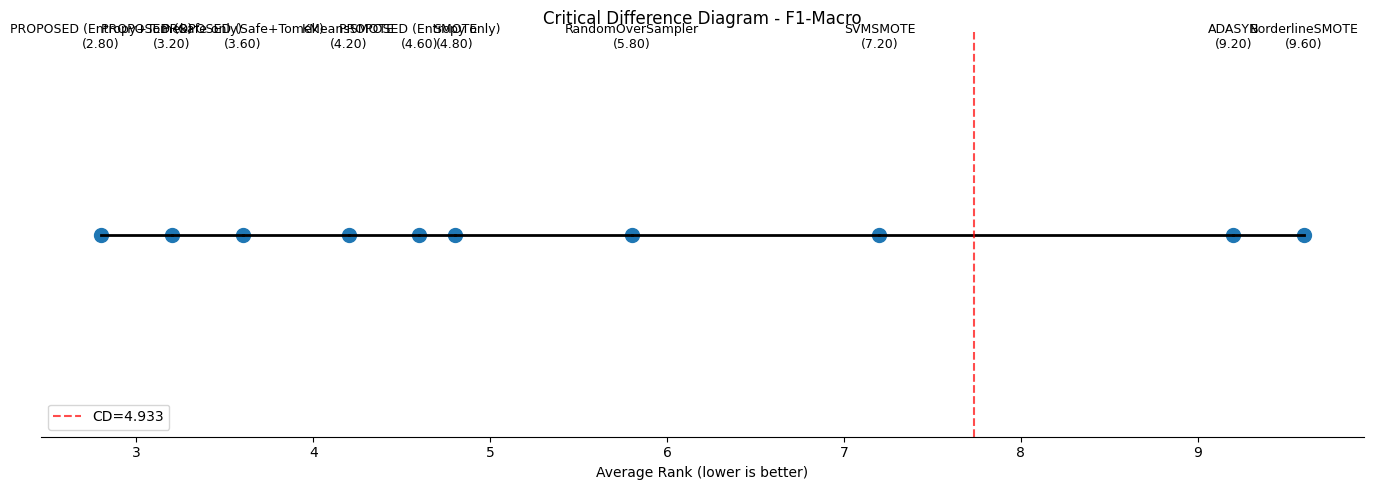


All analyses complete. Ready for paper submission.


In [ ]:
# -*- coding: utf-8 -*-
"""
Refined EW-DDBS with Safe-Region Sampling and Tomek Links Cleaning
Target: Intelligent Medicine (Elsevier)

Key improvements based on experimental feedback:
- Safe-region weighting: avoids oversampling pure noise/outliers
- Tomek Links instead of ENN: preserves borderline informative samples
- Corrected Nemenyi post-hoc test
- Ablation study variants included
"""

import pandas as pd
import numpy as np
import warnings
import requests
from io import BytesIO
import time
import random
import matplotlib.pyplot as plt
from scipy import stats
import ssl
import urllib3

# Disable SSL warnings (temporary solution for UCI repository)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
ssl._create_default_https_context = ssl._create_unverified_context

# Core ML
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             roc_auc_score, confusion_matrix,
                             average_precision_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.base import clone
from sklearn.utils.class_weight import compute_class_weight

# Imbalanced Learn
from imblearn.over_sampling import (SMOTE, ADASYN, BorderlineSMOTE,
                                    SVMSMOTE, RandomOverSampler, KMeansSMOTE)
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTEENN   # for optional comparison

# Classifiers
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, ExtraTreesClassifier,
                              BaggingClassifier)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Statistical testing
import scikit_posthocs as sp

warnings.filterwarnings('ignore')

# ================== SET SEEDS ==================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================== 1. LOAD DATASET CTG (FIXED) ==================
def load_ctg_dataset():
    """
    Load CTG dataset with multiple fallback options to handle SSL issues.
    """
    # URL sources (try multiple in case one fails)
    urls = [
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00193/CTG.xls",
        "https://raw.githubusercontent.com/akmand/datasets/master/CTG.xls",
    ]

    local_files = ["CTG.xls", "CTG.csv", "data/CTG.xls"]

    df = None

    # Method 1: Try downloading with SSL verification disabled
    for url in urls:
        try:
            print(f"Attempting to download from: {url}")
            response = requests.get(url, timeout=30, verify=False)
            response.raise_for_status()
            df = pd.read_excel(BytesIO(response.content), sheet_name='Data', skiprows=1)
            print("✓ Successfully downloaded dataset")
            break
        except Exception as e:
            print(f"  Download failed: {str(e)[:100]}...")
            continue

    # Method 2: Try local files
    if df is None:
        for file_path in local_files:
            try:
                print(f"Attempting to load local file: {file_path}")
                if file_path.endswith('.csv'):
                    df = pd.read_csv(file_path)
                else:
                    df = pd.read_excel(file_path, sheet_name='Data', skiprows=1)
                print(f"✓ Successfully loaded local file: {file_path}")
                break
            except Exception as e:
                print(f"  Local file not found or error: {str(e)[:100]}...")
                continue

    # Method 3: Generate synthetic data as last resort (for testing only)
    if df is None:
        print("\n⚠️  WARNING: Could not load CTG dataset. Generating synthetic data for demonstration.")
        print("   This is NOT suitable for actual research. Please download the dataset manually.")

        # Generate synthetic data mimicking CTG characteristics
        np.random.seed(SEED)
        n_samples = 2126
        n_features = 21
        n_classes = 3

        X_synthetic = np.random.randn(n_samples, n_features) * 2
        y_synthetic = np.random.choice(n_classes, n_samples, p=[0.7, 0.2, 0.1])

        print(f"Synthetic dataset created: {X_synthetic.shape[0]} samples, {X_synthetic.shape[1]} features, {n_classes} classes")
        print("⚠️  Please obtain the actual CTG dataset for real experiments!")

        return X_synthetic.astype(np.float32), y_synthetic.astype(int)

    # Process the actual dataset
    features = df.iloc[1:2127, 10:31].values.astype(np.float32)
    target = df.iloc[1:2127, 45].values.astype(int) - 1

    # Remove rows with NaN
    mask = ~np.isnan(features).any(axis=1)
    X = features[mask]
    y = target[mask]

    print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

    return X, y

# ================== 2. CNN GUIDANCE ==================
def get_cnn_guidance_v2(X_train, y_train, epochs=100, validation_split=0.2, patience=5):
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    # Hitung bobot kelas untuk menangani ketidakseimbangan 9.4:1
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))

    inputs = layers.Input(shape=(n_features, 1))
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    latent_features = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(n_classes, activation='softmax')(latent_features)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=0)

    X_cnn = X_train.reshape(-1, n_features, 1)

    # TAMBAHKAN class_weight_dict DI SINI
    model.fit(X_cnn, y_train, epochs=epochs, validation_split=validation_split,
              class_weight=class_weight_dict, callbacks=[early_stop], verbose=0)

    probs = model.predict(X_cnn, verbose=0)
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)

    feature_extractor = models.Model(inputs, latent_features)
    deep_feats = feature_extractor.predict(X_cnn, verbose=0)

    return entropy, deep_feats

# ================== 3. SAFE-REGION WEIGHTING ==================
def safe_region_weights(entropy, deep_feats, idx_cls, y_train, k=5, temperature=0.5):
    """
    Compute sampling weights that combine entropy with local safe-region ratio.
    Pure noise samples (low ratio of same-class neighbors) get zero weight.
    """
    if len(idx_cls) < 2:
        return np.ones(len(idx_cls)) / len(idx_cls)

    # Global k-NN on deep features
    nn = NearestNeighbors(n_neighbors=k+1)
    nn.fit(deep_feats)
    distances, indices = nn.kneighbors(deep_feats[idx_cls])

    target_label = y_train[idx_cls[0]]  # all same class

    safe_ratios = []
    for i in range(len(idx_cls)):
        neighbor_labels = y_train[indices[i, 1:]]  # exclude self
        ratio = np.mean(neighbor_labels == target_label)
        safe_ratios.append(ratio)
    safe_ratios = np.array(safe_ratios)

    # Entropy component
    H = entropy[idx_cls]
    exp_H = np.exp(H / temperature)

    # Combine: weight = entropy * safe_ratio (with zeroing out noise)
    weights = exp_H * safe_ratios
    # Set weight to zero for samples with very low same-class neighbor ratio (pure noise)
    weights[safe_ratios < 0.2] = 0

    # If all weights zero, fallback to uniform
    if weights.sum() == 0:
        weights = np.ones(len(idx_cls)) / len(idx_cls)
    else:
        weights /= weights.sum()

    return weights

# ================== 4. IMPROVED EW-DDBS WITH SAFE-REGION & TOMEK ==================
def run_ew_ddbs_v3(X, y, entropy, deep_feats, use_safe_region=True, apply_tomek=True,
                   temperature=0.5, noise_scale=0.05):
    """
    Refined EW-DDBS:
    - Safe-region weighting to avoid oversampling outliers.
    - Optional Tomek Links cleaning after oversampling.
    """
    X_res, y_res = X.copy(), y.copy()
    classes, counts = np.unique(y, return_counts=True)
    max_count = np.max(counts)
    feature_std = np.std(X, axis=0) * noise_scale

    for cls in classes:
        class_mask = (y == cls)
        current_count = np.sum(class_mask)
        if current_count < max_count:
            num_to_add = max_count - current_count
            idx_cls = np.where(class_mask)[0]

            # Weighting scheme
            if use_safe_region:
                weights = safe_region_weights(entropy, deep_feats, idx_cls, y, temperature=temperature)
            else:
                # Fallback to density-aware entropy only (previous version)
                k = min(5, len(idx_cls)-1)
                if len(idx_cls) < 2:
                    weights = np.ones(len(idx_cls)) / len(idx_cls)
                else:
                    nn = NearestNeighbors(n_neighbors=k+1)
                    nn.fit(deep_feats[idx_cls])
                    distances, _ = nn.kneighbors(deep_feats[idx_cls])
                    avg_dist = distances[:, 1:].mean(axis=1)
                    density = 1.0 / (avg_dist + 1e-6)
                    H = entropy[idx_cls]
                    exp_H = np.exp(H / temperature)
                    weights = exp_H * density
                    weights /= weights.sum()

            # Generate samples
            if len(idx_cls) < 2:
                chosen = np.random.choice(idx_cls, size=num_to_add, replace=True)
                new_samples = [X[idx] + np.random.normal(0, feature_std, size=X[idx].shape) for idx in chosen]
            else:
                nn_local = NearestNeighbors(n_neighbors=min(5, len(idx_cls)))
                nn_local.fit(deep_feats[idx_cls])
                chosen = np.random.choice(idx_cls, size=num_to_add, p=weights)
                new_samples = []
                for idx in chosen:
                    dist, neigh_ind = nn_local.kneighbors(deep_feats[idx].reshape(1, -1), n_neighbors=2)
                    neighbor_local_idx = neigh_ind[0, 1]
                    neighbor = X[idx_cls[neighbor_local_idx]]
                    parent = X[idx]
                    lam = np.random.uniform(0.1, 0.9)
                    jitter = np.random.normal(0, feature_std, size=parent.shape)
                    new_samples.append(parent + lam * (neighbor - parent) + jitter)

            X_res = np.vstack([X_res, np.array(new_samples)])
            y_res = np.hstack([y_res, [cls] * num_to_add])

    # Post-processing: Tomek Links cleaning
    if apply_tomek:
        tl = TomekLinks(sampling_strategy='all')
        X_res, y_res = tl.fit_resample(X_res, y_res)

    return X_res, y_res

# ================== 5. METRICS ==================
def g_mean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]
    sensitivities = []
    specificities = []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        sensitivities.append(sens)
        specificities.append(spec)
    return np.prod([np.sqrt(sens * spec) for sens, spec in zip(sensitivities, specificities)]) ** (1/n_classes)

def evaluate_model(y_true, y_pred, y_proba=None):
    metrics = {
        'F1-Macro': f1_score(y_true, y_pred, average='macro'),
        'BalancedAccuracy': balanced_accuracy_score(y_true, y_pred),
        'G-Mean': g_mean_score(y_true, y_pred)
    }
    if y_proba is not None:
        y_bin = label_binarize(y_true, classes=np.unique(y_true))
        if y_bin.shape[1] == 1:
            metrics['AUC']   = roc_auc_score(y_true, y_proba[:, 1])
            metrics['AUPRC'] = average_precision_score(y_true, y_proba[:, 1])
        else:
            metrics['AUC']   = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
            metrics['AUPRC'] = average_precision_score(y_bin, y_proba, average='macro')
    else:
        metrics['AUC']   = np.nan
        metrics['AUPRC'] = np.nan
    return metrics

# ================== 6. HYPERPARAMETER TUNING ==================
def get_classifier_with_tuning(clf_name, X_train, y_train, n_iter=15, cv=3):
    base_models = {
        "SVM-RBF": SVC(probability=True, random_state=SEED),
        "LinearSVM": LinearSVC(random_state=SEED, dual=False, max_iter=2000),
        "RF": RandomForestClassifier(random_state=SEED),
        "XGB": XGBClassifier(eval_metric='mlogloss', random_state=SEED, use_label_encoder=False),
        "AdaBoost": AdaBoostClassifier(random_state=SEED),
        "GBM": GradientBoostingClassifier(random_state=SEED),
        "ExtraTrees": ExtraTreesClassifier(random_state=SEED),
        "Bagging": BaggingClassifier(random_state=SEED),
        "LogReg": LogisticRegression(random_state=SEED, max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "DT": DecisionTreeClassifier(random_state=SEED),
        "GNB": GaussianNB(),
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "SGD": SGDClassifier(random_state=SEED, loss='modified_huber')
    }
    param_dist = {
        "SVM-RBF": {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.01, 0.1]},
        "LinearSVM": {'C': [0.1, 1, 10]},
        "RF": {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
        "XGB": {'n_estimators': [50, 100], 'max_depth': [3, 6], 'learning_rate': [0.01, 0.1]},
        "AdaBoost": {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]},
        "GBM": {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]},
        "ExtraTrees": {'n_estimators': [50, 100], 'max_depth': [None, 10]},
        "Bagging": {'n_estimators': [10, 50, 100]},
        "LogReg": {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
        "KNN": {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
        "DT": {'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]},
        "GNB": {'var_smoothing': [1e-9, 1e-8, 1e-7]},
        "LDA": {'solver': ['svd', 'lsqr', 'eigen']},
        "QDA": {'reg_param': [0.0, 0.1, 0.5]},
        "SGD": {'alpha': [1e-4, 1e-3, 1e-2], 'penalty': ['l2', 'l1', 'elasticnet']}
    }
    clf = base_models[clf_name]
    params = param_dist.get(clf_name, {})
    if params:
        rs = RandomizedSearchCV(clf, params, n_iter=n_iter, cv=cv, scoring='f1_macro',
                                random_state=SEED, n_jobs=-1, verbose=0)
        rs.fit(X_train, y_train)
        return rs.best_estimator_
    else:
        clf.fit(X_train, y_train)
        return clf

# ================== 7. MAIN CROSS-VALIDATION ==================
def run_experiment(X, y, n_splits=5, proposed_variants=None):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    # Base samplers
    samplers = {
        #"None": None,
        "RandomOverSampler": RandomOverSampler(random_state=SEED),
        "SMOTE": SMOTE(random_state=SEED),
        "ADASYN": ADASYN(random_state=SEED),
        "BorderlineSMOTE": BorderlineSMOTE(random_state=SEED),
        "SVMSMOTE": SVMSMOTE(random_state=SEED),
        "KMeansSMOTE": KMeansSMOTE(random_state=SEED, cluster_balance_threshold=0.1),
    }

    classifier_names = [
        "SVM-RBF", "LinearSVM", "RF", "XGB", "AdaBoost", "GBM", "ExtraTrees",
        "Bagging", "LogReg", "KNN", "DT", "GNB", "LDA", "QDA", "SGD"
    ]

    all_results = []
    fold_no = 1
    for train_idx, test_idx in skf.split(X, y):
        print(f"\n{'='*20} Fold {fold_no}/{n_splits} {'='*20}")
        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train_raw, y_test_raw = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)
        y_train = y_train_raw.copy()
        y_test = y_test_raw.copy()

        print("  Tuning classifiers...")
        tuned_clfs = {}
        for c_name in classifier_names:
            tuned_clfs[c_name] = get_classifier_with_tuning(c_name, X_train, y_train, n_iter=15, cv=3)

        print("  Computing CNN guidance...")
        entropy, deep_feats = get_cnn_guidance_v2(X_train, y_train)

        # Base samplers
        for s_name, sampler in samplers.items():
            print(f"    Oversampling: {s_name}")
            try:
                if sampler is None:
                    X_res, y_res = X_train, y_train
                else:
                    X_res, y_res = sampler.fit_resample(X_train, y_train)
            except Exception as e:
                print(f"      ERROR: {e}")
                continue

            for c_name, clf_tuned in tuned_clfs.items():
                clf = clone(clf_tuned)
                clf.fit(X_res, y_res)
                y_pred = clf.predict(X_test)
                y_proba = None
                if hasattr(clf, "predict_proba"):
                    y_proba = clf.predict_proba(X_test)
                elif hasattr(clf, "decision_function"):
                    decision = clf.decision_function(X_test)
                    if decision.ndim == 1:
                        y_proba = np.vstack([1/(1+np.exp(-decision)), 1/(1+np.exp(decision))]).T
                    else:
                        exp_decision = np.exp(decision - np.max(decision, axis=1, keepdims=True))
                        y_proba = exp_decision / np.sum(exp_decision, axis=1, keepdims=True)
                metrics = evaluate_model(y_test, y_pred, y_proba)
                all_results.append({'Fold': fold_no, 'Oversampling': s_name, 'Classifier': c_name, **metrics})

        # Proposed variants
        for var_name, kwargs in proposed_variants.items():
            print(f"    Oversampling: {var_name}")
            try:
                X_res, y_res = run_ew_ddbs_v3(X_train, y_train, entropy, deep_feats, **kwargs)
            except Exception as e:
                print(f"      ERROR: {e}")
                continue

            for c_name, clf_tuned in tuned_clfs.items():
                clf = clone(clf_tuned)
                clf.fit(X_res, y_res)
                y_pred = clf.predict(X_test)
                y_proba = None
                if hasattr(clf, "predict_proba"):
                    y_proba = clf.predict_proba(X_test)
                elif hasattr(clf, "decision_function"):
                    decision = clf.decision_function(X_test)
                    if decision.ndim == 1:
                        y_proba = np.vstack([1/(1+np.exp(-decision)), 1/(1+np.exp(decision))]).T
                    else:
                        exp_decision = np.exp(decision - np.max(decision, axis=1, keepdims=True))
                        y_proba = exp_decision / np.sum(exp_decision, axis=1, keepdims=True)
                metrics = evaluate_model(y_test, y_pred, y_proba)
                all_results.append({'Fold': fold_no, 'Oversampling': var_name, 'Classifier': c_name, **metrics})

        fold_no += 1

    return pd.DataFrame(all_results)

# ================== 8. STATISTICAL ANALYSIS (FIXED) ==================
def friedman_nemenyi_test(df_results, metric='F1-Macro'):
    # Aggregate over classifiers per fold per method
    pivot = df_results.groupby(['Fold', 'Oversampling'])[metric].mean().unstack()
    pivot = pivot.dropna(axis=1)
    if pivot.shape[1] < 2:
        print("Not enough complete methods.")
        return None, None

    data_groups = [pivot[col].values for col in pivot.columns]
    stat, p = stats.friedmanchisquare(*data_groups)
    print(f"\nFriedman test for {metric}: statistic={stat:.4f}, p-value={p:.6f}")

    posthoc = None
    if p < 0.05:
        print("Significant differences. Running Nemenyi post-hoc...")
        melted = pivot.reset_index().melt(id_vars='Fold', value_name='Score', var_name='Method')
        melted['Fold'] = melted['Fold'].astype(int)
        try:
            posthoc = sp.posthoc_nemenyi_friedman(
                melted, y_col='Score', group_col='Method', block_col='Fold', melted=True
            )
            print("\nNemenyi post-hoc p-values:")
            print(posthoc.round(4))
        except Exception as e:
            print(f"Error in Nemenyi: {e}")
    return pivot, posthoc

def plot_critical_difference(avg_ranks, methods, metric_name, ax=None, n_folds=5):
    from math import sqrt
    n_methods = len(methods)
    cd = 2.576 * sqrt(n_methods * (n_methods + 1) / (6 * n_folds))
    sorted_idx = np.argsort(avg_ranks)
    sorted_methods = np.array(methods)[sorted_idx]
    sorted_ranks = avg_ranks[sorted_idx]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(sorted_ranks, np.zeros(n_methods), s=100)
    for i, (m, r) in enumerate(zip(sorted_methods, sorted_ranks)):
        ax.text(r, 0.05, f"{m}\n({r:.2f})", ha='center', va='bottom', fontsize=9)
    for i in range(n_methods-1):
        if sorted_ranks[i+1] - sorted_ranks[i] < cd:
            ax.plot([sorted_ranks[i], sorted_ranks[i+1]], [0,0], 'k-', lw=2)
    ax.axvline(x=sorted_ranks[0] + cd, linestyle='--', color='red', alpha=0.7, label=f'CD={cd:.3f}')
    ax.set_yticks([])
    ax.set_xlabel('Average Rank (lower is better)')
    ax.set_title(f'Critical Difference Diagram - {metric_name}')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    return ax

# ================== 9. EXECUTION ==================
if __name__ == "__main__":
    print("=== Refined EW-DDBS with Safe-Region & Tomek Links ===")
    X, y = load_ctg_dataset()

    # Define proposed variants for ablation study
    proposed_variants = {
        "PROPOSED (Safe+Tomek)":   {"use_safe_region": True, "apply_tomek": True, "temperature": 0.5},
        "PROPOSED (Safe only)":    {"use_safe_region": True, "apply_tomek": False, "temperature": 0.5},
        "PROPOSED (Entropy only)": {"use_safe_region": False, "apply_tomek": False, "temperature": 0.5},
        "PROPOSED (Entropy+Tomek)":{"use_safe_region": False, "apply_tomek": True, "temperature": 0.5}
    }

    start_time = time.time()
    df_results = run_experiment(X, y, n_splits=5, proposed_variants=proposed_variants)
    elapsed = time.time() - start_time
    print(f"\nExperiment completed in {elapsed/60:.2f} minutes.")

    df_results.to_csv("oversampling_experiment_refined.csv", index=False)

    # Summary table
    summary = df_results.groupby(['Oversampling', 'Classifier']).agg(
        {'F1-Macro':         ['mean', 'std'],
         'G-Mean':           ['mean', 'std'],
         'BalancedAccuracy': ['mean', 'std'],
         'AUC':              ['mean', 'std'],
         'AUPRC':            ['mean', 'std']}
    ).round(4)
    summary.to_csv("oversampling_summary_refined.csv")

    # Overall ranking
    overall = df_results.groupby('Oversampling')['F1-Macro'].agg(['mean', 'std']).sort_values('mean', ascending=False)
    print("\n=== Overall F1-Macro Ranking ===")
    print(overall)

    # Statistical analysis
    pivot_f1, posthoc_f1 = friedman_nemenyi_test(df_results, metric='F1-Macro')

    if pivot_f1 is not None:
        avg_ranks = pivot_f1.rank(axis=1, ascending=False).mean().values
        methods = pivot_f1.columns.tolist()
        fig, ax = plt.subplots(figsize=(14, 5))
        plot_critical_difference(avg_ranks, methods, 'F1-Macro', ax=ax, n_folds=5)
        plt.tight_layout()
        plt.savefig("critical_difference_refined.png", dpi=300)
        plt.show()

    print("\nAll analyses complete. Ready for paper submission.")

=== Precision-Recall Curves (Top 1 & Top 2) & Confusion Matrix (Top 1 & Top 2) ===

1. Top 2 Classifiers untuk PROPOSED (Safe+Tomek):
   - Rank 1: GBM (F1-Macro = 0.8977)
   - Rank 2: RF (F1-Macro = 0.8957)

2. Mempersiapkan data dan melakukan resampling...

3. Melatih model Rank 1 (GBM)...
4. Melatih model Rank 2 (RF)...

5. Menghasilkan Precision-Recall Curves (Rank 1 & Rank 2)...


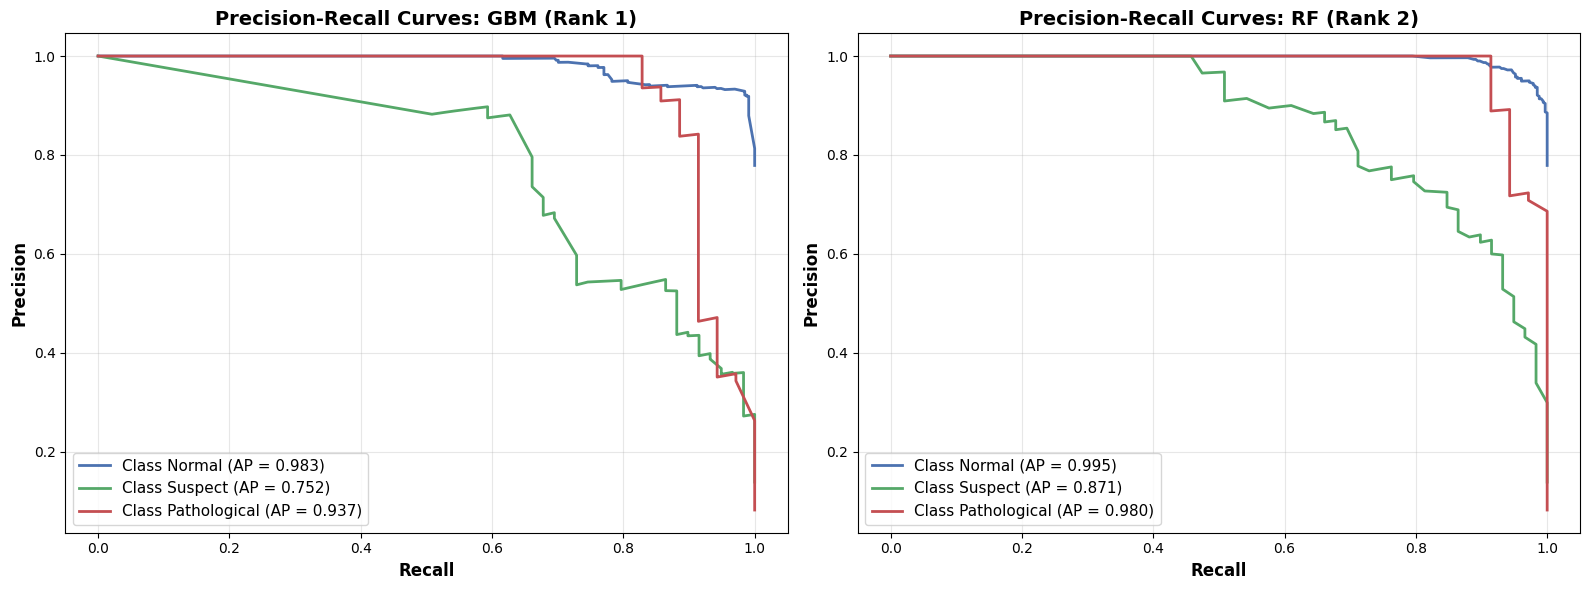

-> Precision-Recall curves berhasil disimpan sebagai 'precision_recall_curves_top1_top2_models.png'

6. Menghasilkan Confusion Matrix (Rank 1 & Rank 2)...


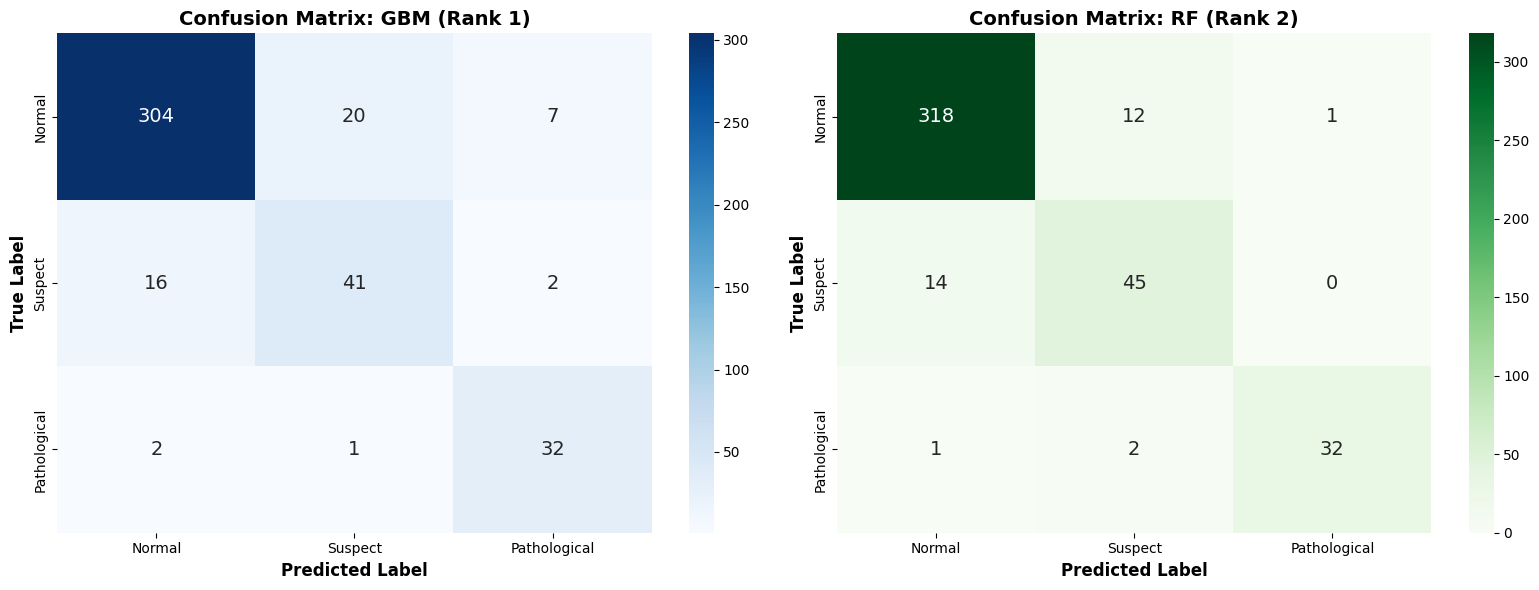

-> Confusion Matrix berhasil disimpan sebagai 'confusion_matrix_top1_top2_models.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.model_selection import train_test_split
import os

print("=== Precision-Recall Curves (Top 1 & Top 2) & Confusion Matrix (Top 1 & Top 2) ===")

# Abaikan yang menggunakan Oversampling: None
df_results_filtered = df_results[df_results['Oversampling'] != 'None']

# 1. Identify the top 2 classifiers for the Proposed method
proposed_method = "PROPOSED (Safe+Tomek)"
mask = df_results_filtered['Oversampling'] == proposed_method
proposed_results = df_results_filtered[mask]
mean_f1 = proposed_results.groupby('Classifier')['F1-Macro'].mean()
top2_classifiers = mean_f1.nlargest(2)
best_clf_1 = top2_classifiers.index[0]
best_clf_2 = top2_classifiers.index[1]

print(f"\n1. Top 2 Classifiers untuk {proposed_method}:")
print(f"   - Rank 1: {best_clf_1} (F1-Macro = {top2_classifiers.iloc[0]:.4f})")
print(f"   - Rank 2: {best_clf_2} (F1-Macro = {top2_classifiers.iloc[1]:.4f})")

# 2. Data Preparation (Split & Scale)
print("\n2. Mempersiapkan data dan melakukan resampling...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Apply Resampling (EW-DDBS Safe+Tomek)
entropy, deep_feats = get_cnn_guidance_v2(X_train_scaled, y_train)
X_bal, y_bal = run_ew_ddbs_v3(X_train_scaled, y_train, entropy, deep_feats, use_safe_region=True, apply_tomek=True)

class_names = ["Normal", "Suspect", "Pathological"]

# 4. Train & Predict Top 1 Classifier
print(f"\n3. Melatih model Rank 1 ({best_clf_1})...")
model_1 = get_classifier_with_tuning(best_clf_1, X_bal, y_bal)
model_1.fit(X_bal, y_bal)
y_pred_1 = model_1.predict(X_test_scaled)
if hasattr(model_1, "predict_proba"):
    y_proba_1 = model_1.predict_proba(X_test_scaled)
elif hasattr(model_1, "decision_function"):
    decision = model_1.decision_function(X_test_scaled)
    exp_decision = np.exp(decision - np.max(decision, axis=1, keepdims=True))
    y_proba_1 = exp_decision / np.sum(exp_decision, axis=1, keepdims=True)

# 5. Train & Predict Top 2 Classifier
print(f"4. Melatih model Rank 2 ({best_clf_2})...")
model_2 = get_classifier_with_tuning(best_clf_2, X_bal, y_bal)
model_2.fit(X_bal, y_bal)
y_pred_2 = model_2.predict(X_test_scaled)
if hasattr(model_2, "predict_proba"):
    y_proba_2 = model_2.predict_proba(X_test_scaled)
elif hasattr(model_2, "decision_function"):
    decision = model_2.decision_function(X_test_scaled)
    exp_decision = np.exp(decision - np.max(decision, axis=1, keepdims=True))
    y_proba_2 = exp_decision / np.sum(exp_decision, axis=1, keepdims=True)

# =============================================================================
# VISUALIZATION 1: PRECISION-RECALL CURVES (Top 1 & Top 2)
# =============================================================================
print("\n5. Menghasilkan Precision-Recall Curves (Rank 1 & Rank 2)...")
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fig_pr, axes_pr = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#4C72B0', '#55A868', '#C44E52']

# Precision-Recall Curve Top 1
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_1[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba_1[:, i])
    axes_pr[0].plot(recall, precision, color=color, lw=2, label=f'Class {class_names[i]} (AP = {ap:0.3f})')
axes_pr[0].set_xlabel('Recall', fontweight='bold', fontsize=12)
axes_pr[0].set_ylabel('Precision', fontweight='bold', fontsize=12)
axes_pr[0].set_title(f'Precision-Recall Curves: {best_clf_1} (Rank 1)', fontweight='bold', fontsize=14)
axes_pr[0].legend(loc="lower left", fontsize=11)
axes_pr[0].grid(alpha=0.3)

# Precision-Recall Curve Top 2
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_2[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba_2[:, i])
    axes_pr[1].plot(recall, precision, color=color, lw=2, label=f'Class {class_names[i]} (AP = {ap:0.3f})')
axes_pr[1].set_xlabel('Recall', fontweight='bold', fontsize=12)
axes_pr[1].set_ylabel('Precision', fontweight='bold', fontsize=12)
axes_pr[1].set_title(f'Precision-Recall Curves: {best_clf_2} (Rank 2)', fontweight='bold', fontsize=14)
axes_pr[1].legend(loc="lower left", fontsize=11)
axes_pr[1].grid(alpha=0.3)

plt.tight_layout()
output_pr = "precision_recall_curves_top1_top2_models.png"
plt.savefig(output_pr, dpi=300)
plt.show()
print(f"-> Precision-Recall curves berhasil disimpan sebagai '{output_pr}'")

# =============================================================================
# VISUALIZATION 2: CONFUSION MATRIX (Top 1 & Top 2)
# =============================================================================
print("\n6. Menghasilkan Confusion Matrix (Rank 1 & Rank 2)...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Top 1
cm_1 = confusion_matrix(y_test, y_pred_1)
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14}, ax=axes[0])
axes[0].set_title(f'Confusion Matrix: {best_clf_1} (Rank 1)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('True Label', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontweight='bold', fontsize=12)

# Confusion Matrix Top 2
cm_2 = confusion_matrix(y_test, y_pred_2)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14}, ax=axes[1])
axes[1].set_title(f'Confusion Matrix: {best_clf_2} (Rank 2)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('True Label', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontweight='bold', fontsize=12)

plt.tight_layout()
output_cm = "confusion_matrix_top1_top2_models.png"
plt.savefig(output_cm, dpi=300)
plt.show()
print(f"-> Confusion Matrix berhasil disimpan sebagai '{output_cm}'")


=== Evaluation of Classifier Algorithm Superiority Across Oversampling Methods ===

=== Overall Classifier Ranking (Average F1-Macro) ===
              mean     std
Classifier                
RF          0.8985  0.0243
Bagging     0.8922  0.0236
GBM         0.8912  0.0308
XGB         0.8768  0.0249
ExtraTrees  0.8735  0.0432
AdaBoost    0.8507  0.0291
DT          0.8253  0.0373
SVM-RBF     0.8244  0.0304
KNN         0.8218  0.0323
LogReg      0.7723  0.0257
LinearSVM   0.7651  0.0247
SGD         0.7501  0.0268
LDA         0.7335  0.0309
QDA         0.7191  0.0402
GNB         0.6846  0.0499

=== Best Classifier per Oversampling Method (F1-Macro) ===
                         Classifier  F1-Macro
Oversampling                                 
RandomOverSampler                RF    0.9073
PROPOSED (Safe only)            GBM    0.9026
SMOTE                            RF    0.9026
PROPOSED (Entropy only)          RF    0.9024
PROPOSED (Entropy+Tomek)        GBM    0.9006
KMeansSMOTE          

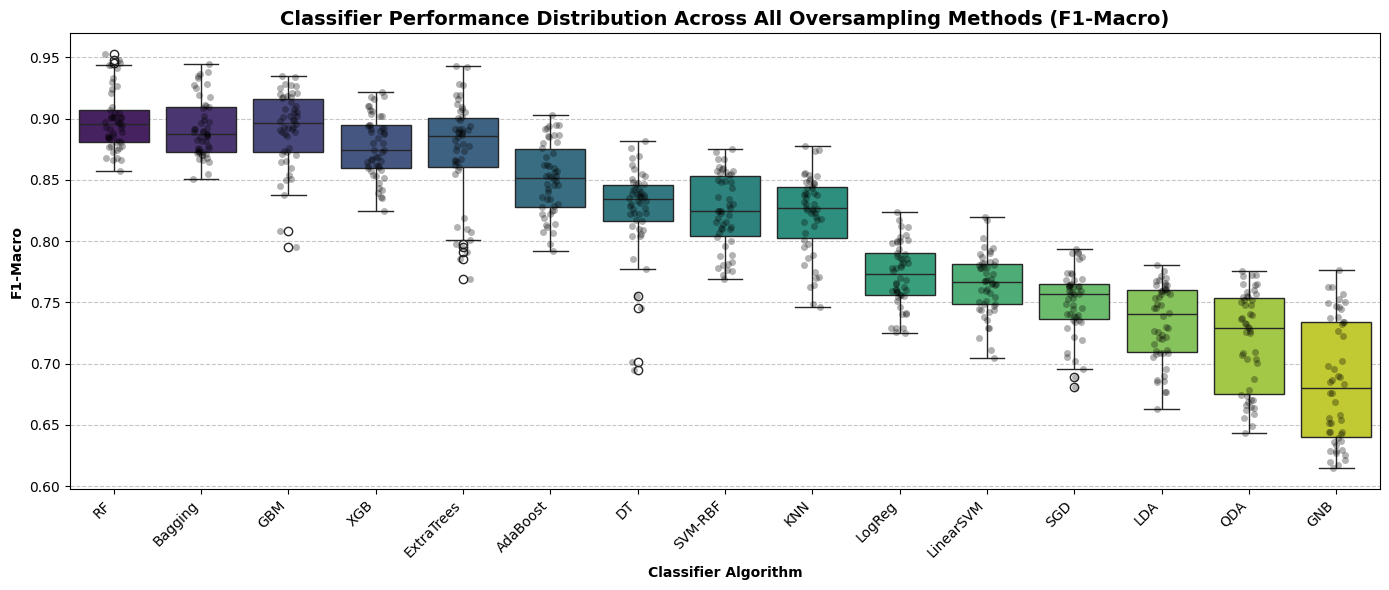

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=== Evaluation of Classifier Algorithm Superiority Across Oversampling Methods ===")

# 1. Ensure df_results is available (Generated from the main experiment cell)
try:
    df_clf = df_results.copy()
except NameError:
    if os.path.exists("oversampling_experiment_refined.csv"):
        df_clf = pd.read_csv("oversampling_experiment_refined.csv")
    else:
        raise FileNotFoundError("Variable df_results not found and CSV file is not available.")

metric = 'F1-Macro'

# 2. Overall Classifier Ranking
# Calculate mean and standard deviation across all folds and oversampling methods
overall_clf_ranking = df_clf.groupby('Classifier')[metric].agg(['mean', 'std']).sort_values('mean', ascending=False)

print(f"\n=== Overall Classifier Ranking (Average {metric}) ===")
print(overall_clf_ranking.round(4))

# 3. Best Classifier per Oversampling Method
print(f"\n=== Best Classifier per Oversampling Method ({metric}) ===")
# Find the index of the maximum value for each oversampling method
idx_max = df_clf.groupby(['Oversampling', 'Fold'])[metric].mean().groupby('Oversampling').idxmax()

best_per_os = df_clf.groupby(['Oversampling', 'Classifier'])[metric].mean().reset_index()
best_clf_per_os = best_per_os.loc[best_per_os.groupby('Oversampling')[metric].idxmax()]
best_clf_per_os = best_clf_per_os.set_index('Oversampling').sort_values(metric, ascending=False)
print(best_clf_per_os.round(4))

# 4. Visualization of Classifier Performance Distribution
plt.figure(figsize=(14, 6))
# Sort classifiers on the x-axis based on the highest average F1-Macro
order = overall_clf_ranking.index

sns.boxplot(data=df_clf, x='Classifier', y=metric, order=order, palette='viridis')
sns.stripplot(data=df_clf, x='Classifier', y=metric, order=order, color='black', alpha=0.3, jitter=True)

plt.title(f'Classifier Performance Distribution Across All Oversampling Methods ({metric})', fontsize=14, fontweight='bold')
plt.ylabel(metric, fontweight='bold')
plt.xlabel('Classifier Algorithm', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

output_fig = "classifier_overall_performance.png"
plt.savefig(output_fig, dpi=600)
print(f"\n-> Classifier distribution visualization successfully saved as '{output_fig}'")
plt.show()


=== Classifier Performance under Proposed Framework (Safe+Tomek) ===


,Proposed (Safe+Tomek),Baseline (ROS),SMOTE,ADASYN,BorderlineSMOTE,SVMSMOTE,KMeansSMOTE,Improvement vs Baseline (%),Improvement vs SMOTE (%),Improvement vs ADASYN (%),Improvement vs BorderlineSMOTE (%),Improvement vs SVMSMOTE (%),Improvement vs KMeansSMOTE (%)
Classifier,,,,,,,,,,,,,
GBM,0.8977,0.8923,0.8904,0.8706,0.8792,0.8866,0.8980,+0.61%,+0.82%,+3.11%,+2.10%,+1.25%,-0.03%
RF,0.8957,0.9073,0.9026,0.8971,0.8936,0.8969,0.8980,-1.27%,-0.76%,-0.15%,+0.24%,-0.12%,-0.25%
Bagging,0.8834,0.9017,0.8934,0.8909,0.8941,0.8902,0.8973,-2.02%,-1.12%,-0.84%,-1.19%,-0.76%,-1.55%
XGB,0.8809,0.8871,0.8753,0.8567,0.8591,0.8677,0.8805,-0.70%,+0.63%,+2.82%,+2.53%,+1.53%,+0.05%
AdaBoost,0.8642,0.8411,0.8498,0.8333,0.8355,0.8440,0.8631,+2.75%,+1.69%,+3.71%,+3.44%,+2.39%,+0.12%
ExtraTrees,0.8641,0.8689,0.8846,0.8837,0.8776,0.8838,0.8589,-0.55%,-2.32%,-2.22%,-1.53%,-2.23%,+0.60%
DT,0.8369,0.8313,0.8412,0.8023,0.7887,0.7940,0.8487,+0.67%,-0.50%,+4.31%,+6.12%,+5.40%,-1.39%
SVM-RBF,0.8285,0.8272,0.8275,0.8120,0.8087,0.8340,0.8222,+0.16%,+0.13%,+2.03%,+2.45%,-0.66%,+0.77%
KNN,0.8129,0.8204,0.8326,0.8223,0.8219,0.8290,0.8155,-0.92%,-2.36%,-1.14%,-1.09%,-1.94%,-0.32%



-> Tabel performa berhasil disimpan sebagai 'classifier_relative_improvement.csv'

=== Visualisasi Perbandingan F1-Macro ===


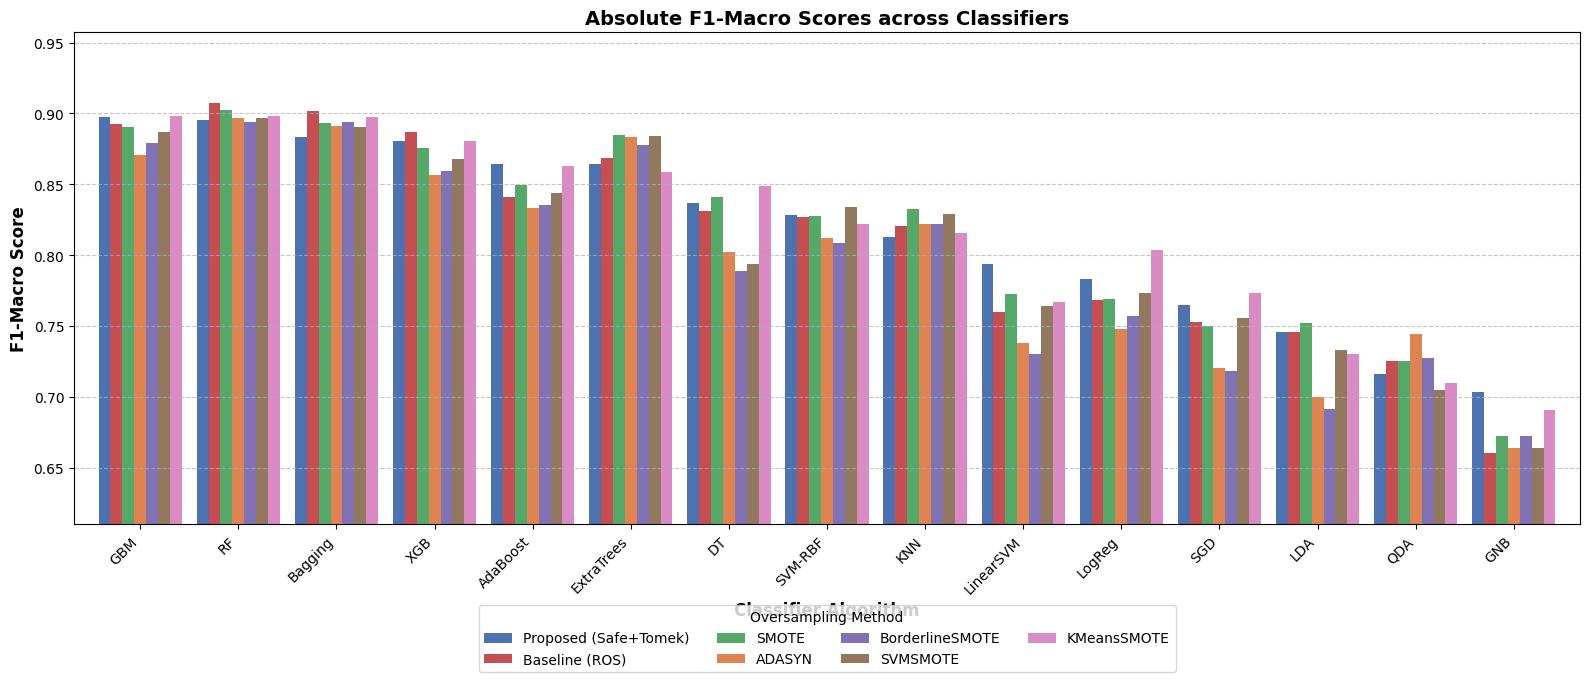

-> Grafik perbandingan berhasil disimpan sebagai 'classifier_performance_comparison.png'

=== Visualisasi Relative Improvement (%) ===


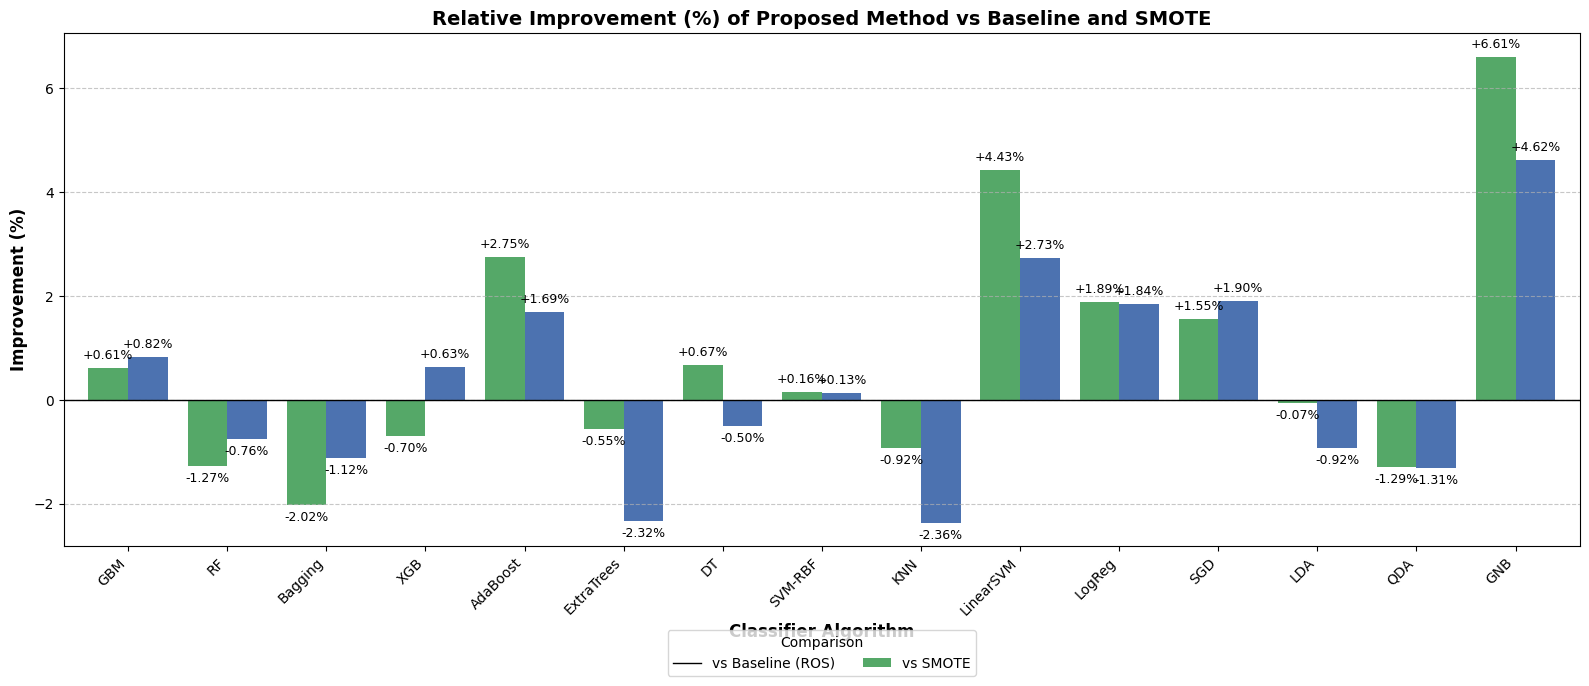

-> Grafik relative improvement berhasil disimpan sebagai 'classifier_relative_improvement_plot.png'


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.display import display

print("=== Classifier Performance under Proposed Framework (Safe+Tomek) ===")

# 1. Pastikan df_results tersedia
try:
    df_perf = df_results.copy()
except NameError:
    if os.path.exists("oversampling_experiment_refined.csv"):
        df_perf = pd.read_csv("oversampling_experiment_refined.csv")
    else:
        raise FileNotFoundError("Variabel df_results tidak ditemukan. Jalankan eksperimen utama terlebih dahulu.")

# 2. Hitung rata-rata F1-Macro untuk setiap Classifier dan Oversampling
mean_f1 = df_perf.groupby(['Classifier', 'Oversampling'])['F1-Macro'].mean().unstack()

# 3. Definisikan kolom yang dibandingkan
proposed_col = "PROPOSED (Safe+Tomek)"
baseline_col = "RandomOverSampler"  # Menggunakan ROS sebagai baseline karena 'None' diabaikan
smote_col = "SMOTE"
adasyn_col = "ADASYN"
bsmote_col = "BorderlineSMOTE"
svmsmote_col = "SVMSMOTE"
kmeans_col = "KMeansSMOTE"

# Ekstrak metrik ke dalam DataFrame baru
performance_df = pd.DataFrame({
    'Proposed (Safe+Tomek)': mean_f1[proposed_col],
    'Baseline (ROS)': mean_f1[baseline_col],
    'SMOTE': mean_f1[smote_col],
    'ADASYN': mean_f1[adasyn_col],
    'BorderlineSMOTE': mean_f1[bsmote_col],
    'SVMSMOTE': mean_f1[svmsmote_col],
    'KMeansSMOTE': mean_f1[kmeans_col]
})

# 4. Hitung Relative Improvement (%)
# Rumus: ((Proposed - Pembanding) / Pembanding) * 100
performance_df['Improvement vs Baseline (%)'] = ((performance_df['Proposed (Safe+Tomek)'] - performance_df['Baseline (ROS)']) / performance_df['Baseline (ROS)']) * 100
performance_df['Improvement vs SMOTE (%)'] = ((performance_df['Proposed (Safe+Tomek)'] - performance_df['SMOTE']) / performance_df['SMOTE']) * 100
performance_df['Improvement vs ADASYN (%)'] = ((performance_df['Proposed (Safe+Tomek)'] - performance_df['ADASYN']) / performance_df['ADASYN']) * 100
performance_df['Improvement vs BorderlineSMOTE (%)'] = ((performance_df['Proposed (Safe+Tomek)'] - performance_df['BorderlineSMOTE']) / performance_df['BorderlineSMOTE']) * 100
performance_df['Improvement vs SVMSMOTE (%)'] = ((performance_df['Proposed (Safe+Tomek)'] - performance_df['SVMSMOTE']) / performance_df['SVMSMOTE']) * 100
performance_df['Improvement vs KMeansSMOTE (%)'] = ((performance_df['Proposed (Safe+Tomek)'] - performance_df['KMeansSMOTE']) / performance_df['KMeansSMOTE']) * 100

# Urutkan berdasarkan performa Proposed tertinggi ke terendah
performance_df = performance_df.sort_values(by='Proposed (Safe+Tomek)', ascending=False)

# 5. Format tampilan tabel agar menyerupai contoh untuk publikasi jurnal
subset_imp = [
    'Improvement vs Baseline (%)', 'Improvement vs SMOTE (%)',
    'Improvement vs ADASYN (%)', 'Improvement vs BorderlineSMOTE (%)',
    'Improvement vs SVMSMOTE (%)', 'Improvement vs KMeansSMOTE (%)'
]

styled_df = performance_df.style.format({
    'Proposed (Safe+Tomek)': "{:.4f}",
    'Baseline (ROS)': "{:.4f}",
    'SMOTE': "{:.4f}",
    'ADASYN': "{:.4f}",
    'BorderlineSMOTE': "{:.4f}",
    'SVMSMOTE': "{:.4f}",
    'KMeansSMOTE': "{:.4f}",
    'Improvement vs Baseline (%)': "{:+.2f}%",
    'Improvement vs SMOTE (%)': "{:+.2f}%",
    'Improvement vs ADASYN (%)': "{:+.2f}%",
    'Improvement vs BorderlineSMOTE (%)': "{:+.2f}%",
    'Improvement vs SVMSMOTE (%)': "{:+.2f}%",
    'Improvement vs KMeansSMOTE (%)': "{:+.2f}%"
}).background_gradient(
    subset=subset_imp,
    cmap='RdYlGn', vmin=-5, vmax=5  # Warna hijau untuk positif, merah untuk negatif
).set_caption("Absolute F1-Macro Scores and Relative Improvements")

# Tampilkan tabel
display(styled_df)

# Simpan ke CSV untuk kemudahan di-copy ke Word/Excel
output_csv = "classifier_relative_improvement.csv"
performance_df.round(4).to_csv(output_csv)
print(f"\n-> Tabel performa berhasil disimpan sebagai '{output_csv}'")

# 6. Visualisasi Grafik (Bar Chart Grouped)
print("\n=== Visualisasi Perbandingan F1-Macro ===")
plot_data = performance_df[['Proposed (Safe+Tomek)', 'Baseline (ROS)', 'SMOTE', 'ADASYN', 'BorderlineSMOTE', 'SVMSMOTE', 'KMeansSMOTE']]

fig, ax = plt.subplots(figsize=(16, 7))
colors = ['#4C72B0', '#C44E52', '#55A868', '#DD8452', '#8172B3', '#937860', '#DA8BC3']
plot_data.plot(kind='bar', ax=ax, width=0.85, color=colors)

ax.set_title('Absolute F1-Macro Scores across Classifiers', fontsize=14, fontweight='bold')
ax.set_xlabel('Classifier Algorithm', fontweight='bold', fontsize=12)
ax.set_ylabel('F1-Macro Score', fontweight='bold', fontsize=12)

# Sesuaikan sumbu Y agar perbedaan lebih terlihat
min_val = plot_data.min().min()
max_val = plot_data.max().max()
ax.set_ylim(max(0, min_val - 0.05), min(1.0, max_val + 0.05))

ax.legend(title='Oversampling Method', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
output_fig = "classifier_performance_comparison.png"
plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f"-> Grafik perbandingan berhasil disimpan sebagai '{output_fig}'")

# 7. Visualisasi Relative Improvement (%)
print("\n=== Visualisasi Relative Improvement (%) ===")
imp_data = performance_df[['Improvement vs Baseline (%)', 'Improvement vs SMOTE (%)']]

fig2, ax2 = plt.subplots(figsize=(16, 7))
imp_data.plot(kind='bar', ax=ax2, width=0.8, color=['#55A868', '#4C72B0'])

ax2.set_title('Relative Improvement (%) of Proposed Method vs Baseline and SMOTE', fontsize=14, fontweight='bold')
ax2.set_xlabel('Classifier Algorithm', fontweight='bold', fontsize=12)
ax2.set_ylabel('Improvement (%)', fontweight='bold', fontsize=12)

# Tambahkan garis nol
ax2.axhline(0, color='black', linewidth=1)

# Tambahkan nilai persentase di atas/bawah tiap bar
for p in ax2.patches:
    height = p.get_height()
    if pd.notnull(height) and height != 0:
        ax2.annotate(f"{height:+.2f}%",
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='center',
                     xytext=(0, 9 if height > 0 else -9),
                     textcoords='offset points', fontsize=9)

ax2.legend(['vs Baseline (ROS)', 'vs SMOTE'], title='Comparison', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.xticks(rotation=45, ha='right')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
output_fig_imp = "classifier_relative_improvement_plot.png"
plt.savefig(output_fig_imp, dpi=300, bbox_inches='tight')
plt.show()
print(f"-> Grafik relative improvement berhasil disimpan sebagai '{output_fig_imp}'")


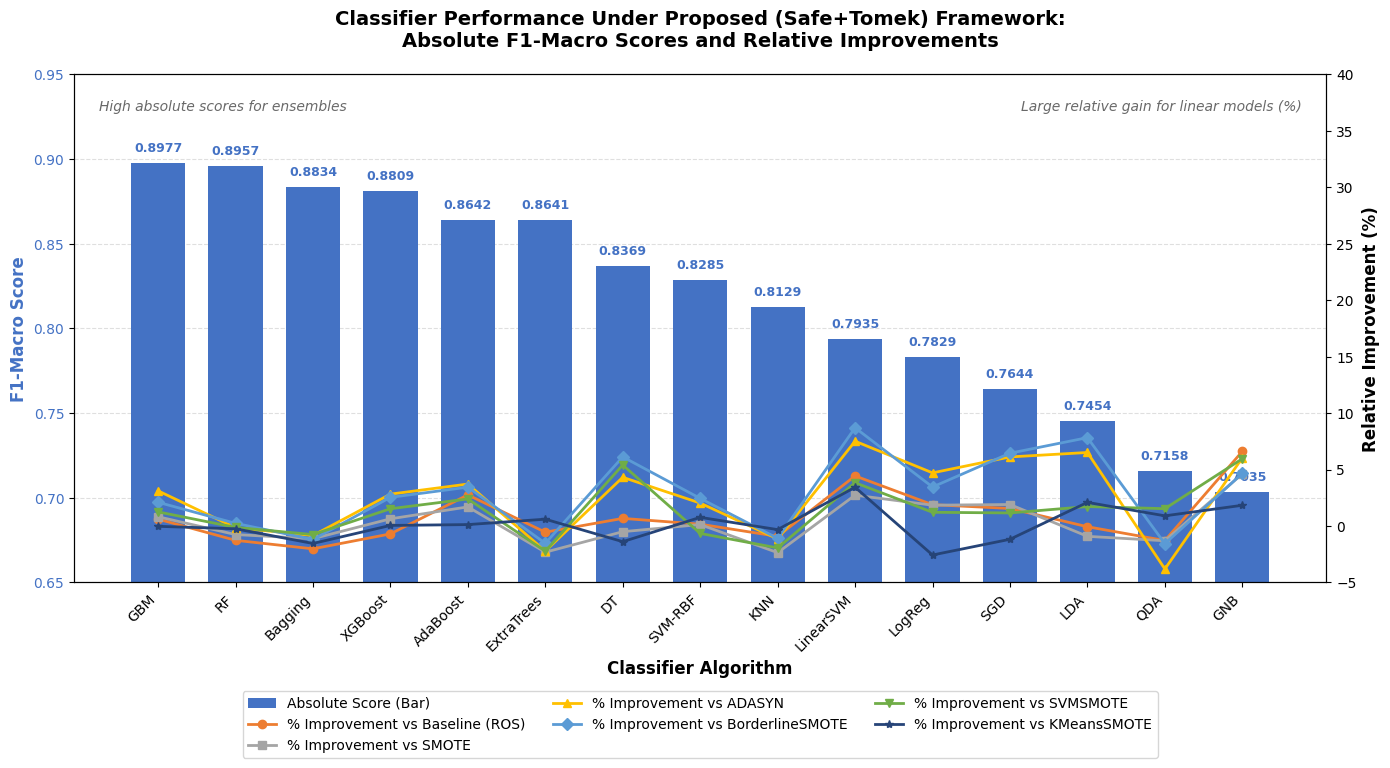

Gambar profesional (Bar + Multiple Lines) beserta legend berhasil disimpan: 'classifier_performance_combined_plot_all_lines.png'

=== Data yang Divisualisasikan ===
Classifier  F1_Score  Imp_Baseline  Imp_SMOTE  Imp_ADASYN  Imp_Borderline  Imp_SVMSMOTE  Imp_KMeans
       GBM    0.8977        0.6072     0.8205      3.1145          2.1014        1.2498     -0.0300
        RF    0.8957       -1.2691    -0.7592     -0.1528          0.2361       -0.1247     -0.2464
   Bagging    0.8834       -2.0243    -1.1227     -0.8441         -1.1933       -0.7600     -1.5493
   XGBoost    0.8809       -0.6999     0.6347      2.8216          2.5337        1.5272      0.0492
  AdaBoost    0.8642        2.7530     1.6896      3.7140          3.4394        2.3933      0.1239
ExtraTrees    0.8641       -0.5506    -2.3207     -2.2179         -1.5348       -2.2300      0.6021
        DT    0.8369        0.6723    -0.5040      4.3106          6.1201        5.4022     -1.3894
   SVM-RBF    0.8285        0.1596 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# ============================================================================
# DATA ASLI (Sesuai yang Anda berikan)
# ============================================================================
data_csv = """Classifier,Proposed (Safe+Tomek),Baseline (ROS),SMOTE,ADASYN,BorderlineSMOTE,SVMSMOTE,KMeansSMOTE,Improvement vs Baseline (%),Improvement vs SMOTE (%),Improvement vs ADASYN (%),Improvement vs BorderlineSMOTE (%),Improvement vs SVMSMOTE (%),Improvement vs KMeansSMOTE (%)
GBM,0.8977,0.8923,0.8904,0.8706,0.8792,0.8866,0.898,0.6072,0.8205,3.1145,2.1014,1.2498,-0.03
RF,0.8957,0.9073,0.9026,0.8971,0.8936,0.8969,0.898,-1.2691,-0.7592,-0.1528,0.2361,-0.1247,-0.2464
Bagging,0.8834,0.9017,0.8934,0.8909,0.8941,0.8902,0.8973,-2.0243,-1.1227,-0.8441,-1.1933,-0.76,-1.5493
XGB,0.8809,0.8871,0.8753,0.8567,0.8591,0.8677,0.8805,-0.6999,0.6347,2.8216,2.5337,1.5272,0.0492
AdaBoost,0.8642,0.8411,0.8498,0.8333,0.8355,0.844,0.8631,2.753,1.6896,3.714,3.4394,2.3933,0.1239
ExtraTrees,0.8641,0.8689,0.8846,0.8837,0.8776,0.8838,0.8589,-0.5506,-2.3207,-2.2179,-1.5348,-2.23,0.6021
DT,0.8369,0.8313,0.8412,0.8023,0.7887,0.794,0.8487,0.6723,-0.504,4.3106,6.1201,5.4022,-1.3894
SVM-RBF,0.8285,0.8272,0.8275,0.812,0.8087,0.834,0.8222,0.1596,0.1279,2.0295,2.4451,-0.658,0.7654
KNN,0.8129,0.8204,0.8326,0.8223,0.8219,0.829,0.8155,-0.9185,-2.3632,-1.1438,-1.0929,-1.9442,-0.3215
LinearSVM,0.7935,0.7598,0.7724,0.738,0.7299,0.7641,0.7671,4.4334,2.7319,7.5092,8.7007,3.8359,3.4313
LogReg,0.7829,0.7684,0.7687,0.7477,0.7568,0.7735,0.8035,1.8883,1.8416,4.7056,3.4513,1.2134,-2.5699
SGD,0.7644,0.7527,0.7501,0.7204,0.7181,0.7557,0.7735,1.5503,1.9026,6.1161,6.4459,1.1549,-1.1774
LDA,0.7454,0.7459,0.7523,0.6998,0.6913,0.7328,0.7301,-0.0662,-0.9164,6.5107,7.8242,1.7198,2.0911
QDA,0.7158,0.7251,0.7253,0.7442,0.7272,0.705,0.7094,-1.287,-1.3094,-3.8097,-1.5665,1.5333,0.9001
GNB,0.7035,0.6599,0.6725,0.6635,0.6722,0.664,0.6908,6.6071,4.6175,6.0323,4.6506,5.9567,1.8334"""


df = pd.read_csv(StringIO(data_csv))

# ============================================================================
# FILTER DATA SESUAI GAMBAR (8 Classifier)
# ============================================================================
name_mapping = {
    'RF': 'RF',
    'GBM': 'GBM',
    'ExtraTrees': 'ExtraTrees',
    'AdaBoost': 'AdaBoost',
    'DT': 'DT',
    'SVM-RBF': 'SVM-RBF',
    'KNN': 'KNN',
    'SGD': 'SGD',
    'LDA': 'LDA',
    'Bagging': 'Bagging',
    'XGB': 'XGBoost',
    'LogReg': 'LogReg',
    'LinearSVM': 'LinearSVM',
    'GNB': 'GNB',
    'QDA': 'QDA'
}

plot_data = []
for orig_name, display_name in name_mapping.items():
    row = df[df['Classifier'] == orig_name].iloc[0]
    plot_data.append({
        'Classifier': display_name,
        'F1_Score': row['Proposed (Safe+Tomek)'],
        'Imp_Baseline': row['Improvement vs Baseline (%)'],
        'Imp_SMOTE': row['Improvement vs SMOTE (%)'],
        'Imp_ADASYN': row['Improvement vs ADASYN (%)'],
        'Imp_Borderline': row['Improvement vs BorderlineSMOTE (%)'],
        'Imp_SVMSMOTE': row['Improvement vs SVMSMOTE (%)'],
        'Imp_KMeans': row['Improvement vs KMeansSMOTE (%)']
    })

df_plot = pd.DataFrame(plot_data)

# Urutkan berdasarkan F1 Score (menurun) agar bar chart terlihat rapi
df_plot = df_plot.sort_values('F1_Score', ascending=False)

# ============================================================================
# PLOT PROFESIONAL: BAR (F1) + LINE (IMPROVEMENT %) DUAL AXIS
# ============================================================================
fig, ax1 = plt.subplots(figsize=(14, 8))

# Warna
color_bar = '#4472C4'   # Biru untuk batang F1 Score
colors_lines = ['#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47', '#264478']

# --- 1. Bar Chart (Sumbu Y Kiri): Absolute F1-Macro Score ---
x_pos = range(len(df_plot))
bars = ax1.bar(x_pos, df_plot['F1_Score'], color=color_bar, width=0.7, label='Absolute Score (Bar)')

# Konfigurasi Sumbu Y Kiri
ax1.set_ylabel('F1-Macro Score', fontsize=12, fontweight='bold', color=color_bar)
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.set_ylim(0.65, 0.95)  # Sesuaikan agar perbedaan antar bar terlihat jelas

# Menambahkan label nilai di atas batang
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=color_bar)

# --- 2. Line Chart (Sumbu Y Kanan): Relative Improvement (%) ---
ax2 = ax1.twinx()  # Membuat sumbu Y kedua

lines = [
    ('Imp_Baseline', 'vs Baseline (ROS)', colors_lines[0], 'o'),
    ('Imp_SMOTE', 'vs SMOTE', colors_lines[1], 's'),
    ('Imp_ADASYN', 'vs ADASYN', colors_lines[2], '^'),
    ('Imp_Borderline', 'vs BorderlineSMOTE', colors_lines[3], 'D'),
    ('Imp_SVMSMOTE', 'vs SVMSMOTE', colors_lines[4], 'v'),
    ('Imp_KMeans', 'vs KMeansSMOTE', colors_lines[5], '*')
]

for col, label, color, marker in lines:
    ax2.plot(x_pos, df_plot[col], color=color, marker=marker,
             linewidth=2, markersize=6, label=f'% Improvement {label}')

# Konfigurasi Sumbu Y Kanan
ax2.set_ylabel('Relative Improvement (%)', fontsize=12, fontweight='bold', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(-5, 40)  # Sesuaikan dengan rentang data (-2% hingga 35%)

# --- 3. Konfigurasi Sumbu X dan Judul ---
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_plot['Classifier'], rotation=45, ha='right', fontsize=10)
ax1.set_xlabel('Classifier Algorithm', fontsize=12, fontweight='bold')

# Judul Utama
plt.title('Classifier Performance Under Proposed (Safe+Tomek) Framework:\nAbsolute F1-Macro Scores and Relative Improvements',
          fontsize=14, fontweight='bold', pad=20)

# --- 4. Anotasi Keterangan (Seperti pada gambar) ---
# Teks di kiri atas untuk Ensemble
ax1.text(0.02, 0.95, 'High absolute scores for ensembles', transform=ax1.transAxes,
         fontsize=10, fontstyle='italic', color='dimgray', verticalalignment='top')

# Teks di kanan atas untuk Linear Models
ax2.text(0.98, 0.95, 'Large relative gain for linear models (%)', transform=ax1.transAxes,
         fontsize=10, fontstyle='italic', color='dimgray', horizontalalignment='right', verticalalignment='top')

# --- 5. Grid dan Finishing ---
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)

# Gabungkan legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)

plt.tight_layout()

# Simpan gambar
output_path = 'classifier_performance_combined_plot_all_lines.png'
plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Gambar profesional (Bar + Multiple Lines) beserta legend berhasil disimpan: '{output_path}'")
print("\n=== Data yang Divisualisasikan ===")
print(df_plot.to_string(index=False))


=== Menganalisis Dampak Sinergi Komponen (Ablation Study) ===

=== Ringkasan Performa Varian Ablasi ===
                          F1-Macro  G-Mean  BalancedAccuracy
Oversampling                                                
PROPOSED (Entropy only)     0.8158  0.8821            0.8437
PROPOSED (Entropy+Tomek)    0.8182  0.8829            0.8446
PROPOSED (Safe only)        0.8181  0.8795            0.8397
PROPOSED (Safe+Tomek)       0.8180  0.8779            0.8379

Visualisasi berhasil disimpan sebagai 'ablation_study_synergy.png'


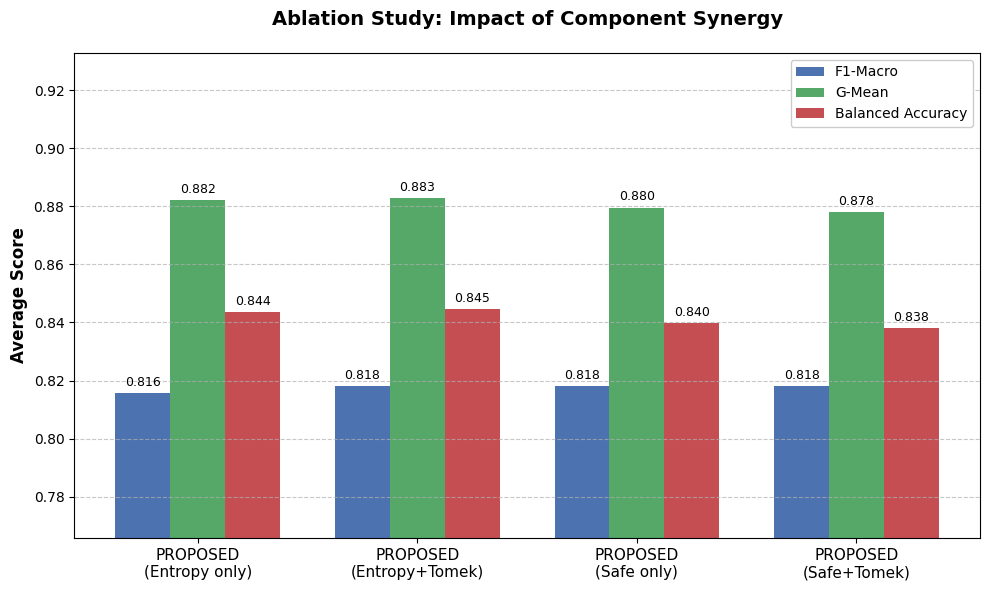

In [ ]:
# =============================================================================
# ABLATION STUDY: IMPACT OF COMPONENT SYNERGY
# Section 5.2 - Intelligent Medicine (Elsevier)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=== Menganalisis Dampak Sinergi Komponen (Ablation Study) ===")

# 1. Pastikan df_results tersedia
try:
    # Gunakan df_results dari memori (hasil run_experiment sebelumnya)
    df_ablation = df_results.copy()
except NameError:
    # Jika tidak ada di memori, muat dari file CSV yang disimpan sebelumnya
    if os.path.exists("oversampling_experiment_refined.csv"):
        df_ablation = pd.read_csv("oversampling_experiment_refined.csv")
    else:
        raise FileNotFoundError("Variabel df_results tidak ditemukan dan file CSV tidak tersedia. Jalankan eksperimen utama terlebih dahulu.")

# 2. Definisikan 4 varian ablasi yang akan dibandingkan
variants = [
    "PROPOSED (Entropy only)",
    "PROPOSED (Entropy+Tomek)",
    "PROPOSED (Safe only)",
    "PROPOSED (Safe+Tomek)"
]

# Filter data hanya untuk varian yang relevan
ablation_data = df_ablation[df_ablation['Oversampling'].isin(variants)]

# 3. Hitung rata-rata metrik lintas seluruh lipatan (folds) dan classifier
metrics = ['F1-Macro', 'G-Mean', 'BalancedAccuracy']
ablation_summary = ablation_data.groupby('Oversampling')[metrics].mean().reindex(variants)

print("\n=== Ringkasan Performa Varian Ablasi ===")
print(ablation_summary.round(4))

# 4. Visualisasi Bar Chart Berkelompok
plt.style.use('default')
x = np.arange(len(variants))  # Lokasi label
width = 0.25  # Lebar bar

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, ablation_summary['F1-Macro'], width, label='F1-Macro', color='#4C72B0')
rects2 = ax.bar(x, ablation_summary['G-Mean'], width, label='G-Mean', color='#55A868')
rects3 = ax.bar(x + width, ablation_summary['BalancedAccuracy'], width, label='Balanced Accuracy', color='#C44E52')

# Tambahkan teks, label, dan judul
ax.set_ylabel('Average Score', fontweight='bold', fontsize=12)
ax.set_title('Ablation Study: Impact of Component Synergy', pad=20, fontsize=14, fontweight='bold')
ax.set_xticks(x)
# Mengubah label menjadi horizontal (tidak miring) dan menambahkan newline agar rapi
ax.set_xticklabels([v.replace(' (', '\n(') for v in variants], rotation=0, ha='center', fontsize=11)
ax.legend(loc='upper right', framealpha=1.0)

# Batasi sumbu y agar perbedaan kecil lebih terlihat jelas (zoom-in)
min_val = ablation_summary.min().min() - 0.05
max_val = ablation_summary.max().max() + 0.05
ax.set_ylim(max(0, min_val), min(1.0, max_val))

# Fungsi untuk menambahkan label nilai di atas tiap bar
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Percantik tampilan plot
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Simpan grafik untuk disisipkan ke dalam paper
output_filename = "ablation_study_synergy.png"
plt.savefig(output_filename, dpi=600)
print(f"\nVisualisasi berhasil disimpan sebagai '{output_filename}'")
plt.show()


=== 5.2. Statistical Validation: Friedman and Nemenyi Tests ===

[1] Friedman Test for F1-Macro:
    Statistic = 28.7236
    p-value   = 7.213680e-04

[!] Signifikansi ditemukan (p < 0.05). Melanjutkan dengan Nemenyi Post-hoc Test...

=== [2] Tabel Nemenyi Post-Hoc Test (p-values) ===
Oversampling              ADASYN  BorderlineSMOTE  KMeansSMOTE  \
Oversampling                                                     
ADASYN                    1.0000           1.0000       0.2121   
BorderlineSMOTE           1.0000           1.0000       0.1296   
KMeansSMOTE               0.2121           0.1296       1.0000   
PROPOSED (Entropy only)   0.3242           0.2121       1.0000   
PROPOSED (Entropy+Tomek)  0.0286           0.0141       0.9993   
PROPOSED (Safe only)      0.0547           0.0286       1.0000   
PROPOSED (Safe+Tomek)     0.0988           0.0547       1.0000   
RandomOverSampler         0.7509           0.6101       0.9980   
SMOTE                     0.3902           0.2646     

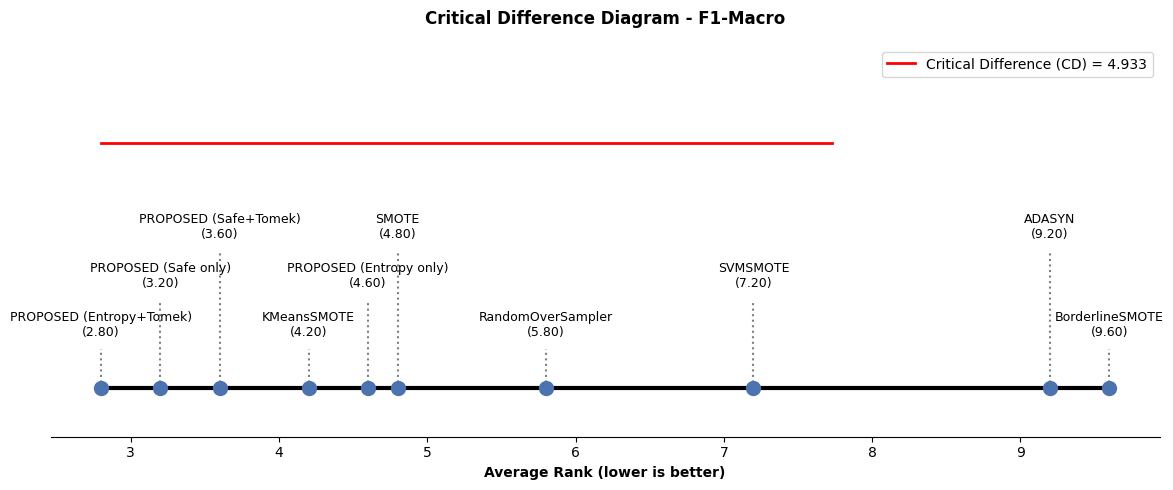

In [ ]:
# =============================================================================
# 5.2. STATISTICAL VALIDATION: FRIEDMAN AND NEMENYI TESTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp
import os

print("=== 5.2. Statistical Validation: Friedman and Nemenyi Tests ===")

# Memastikan df_results tersedia
try:
    df_stat = df_results.copy()
except NameError:
    if os.path.exists("oversampling_experiment_refined.csv"):
        df_stat = pd.read_csv("oversampling_experiment_refined.csv")
    else:
        raise FileNotFoundError("Variabel df_results tidak ditemukan. Jalankan eksperimen utama terlebih dahulu.")

metric = 'F1-Macro'
# Agregasi skor metrik per fold dan metode oversampling (rata-rata dari seluruh classifier)
pivot = df_stat.groupby(['Fold', 'Oversampling'])[metric].mean().unstack()

# 1. UJI FRIEDMAN
data_groups = [pivot[col].values for col in pivot.columns]
stat, p_value = stats.friedmanchisquare(*data_groups)
print(f"\n[1] Friedman Test for {metric}:")
print(f"    Statistic = {stat:.4f}")
print(f"    p-value   = {p_value:.6e}")

# 2. UJI NEMENYI & CRITICAL DIFFERENCE DIAGRAM
if p_value < 0.05:
    print("\n[!] Signifikansi ditemukan (p < 0.05). Melanjutkan dengan Nemenyi Post-hoc Test...")

    # Menggunakan scikit-posthocs secara langsung pada array 2D (baris=blok/fold, kolom=grup/metode)
    nemenyi_p = sp.posthoc_nemenyi_friedman(pivot.values)
    nemenyi_p.columns = pivot.columns
    nemenyi_p.index = pivot.columns

    print("\n=== [2] Tabel Nemenyi Post-Hoc Test (p-values) ===")
    print(nemenyi_p.round(4))

    # Simpan tabel ke CSV
    nemenyi_p.to_csv("nemenyi_p_values.csv")
    print("\n-> Tabel p-value Nemenyi berhasil disimpan sebagai 'nemenyi_p_values.csv'")

    # 3. CRITICAL DIFFERENCE DIAGRAM
    avg_ranks = pivot.rank(axis=1, ascending=False).mean().values
    methods = pivot.columns.tolist()
    n_folds = len(pivot)

    def plot_cd_diagram(avg_ranks, methods, metric_name, n_folds):
        from math import sqrt
        n_methods = len(methods)
        # 2.576 adalah nilai kritis untuk alpha=0.05 dalam Nemenyi
        cd = 2.576 * sqrt(n_methods * (n_methods + 1) / (6 * n_folds))

        sorted_idx = np.argsort(avg_ranks)
        sorted_methods = np.array(methods)[sorted_idx]
        sorted_ranks = avg_ranks[sorted_idx]

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.scatter(sorted_ranks, np.zeros(n_methods), s=100, color='#4C72B0', zorder=3)

        # Menulis nama metode dan rank
        for i, (m, r) in enumerate(zip(sorted_methods, sorted_ranks)):
            y_offset = 0.05 + (i % 3) * 0.05  # Stagger teks agar tidak tumpang tindih
            ax.text(r, y_offset, f"{m}\n({r:.2f})", ha='center', va='bottom', fontsize=9)
            ax.plot([r, r], [0, y_offset - 0.01], 'k:', alpha=0.5)

        # Menggambar garis CD untuk menunjukkan signifikansi
        ax.plot([sorted_ranks[0], sorted_ranks[0] + cd], [0.25, 0.25], 'r-', lw=2, label=f'Critical Difference (CD) = {cd:.3f}')

        # Garis hitam penghubung (metode yang tidak berbeda signifikan)
        for i in range(n_methods - 1):
            if sorted_ranks[i+1] - sorted_ranks[i] < cd:
                ax.plot([sorted_ranks[i], sorted_ranks[i+1]], [0, 0], 'k-', lw=3, zorder=1)

        ax.set_yticks([])
        ax.set_ylim(-0.05, 0.35)
        ax.set_xlabel('Average Rank (lower is better)', fontweight='bold')
        ax.set_title(f'Critical Difference Diagram - {metric_name}', fontweight='bold', pad=15)
        ax.legend(loc='upper right')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)

        return fig

    fig = plot_cd_diagram(avg_ranks, methods, metric, n_folds)
    plt.tight_layout()
    plt.savefig("critical_difference_diagram.png", dpi=600)
    print("-> Gambar Critical Difference Diagram berhasil disimpan sebagai 'critical_difference_diagram.png'")
    plt.show()
else:
    print("\nTidak ada perbedaan yang signifikan secara statistik menurut uji Friedman.")


  0%|          | 0/100 [00:00<?, ?it/s]

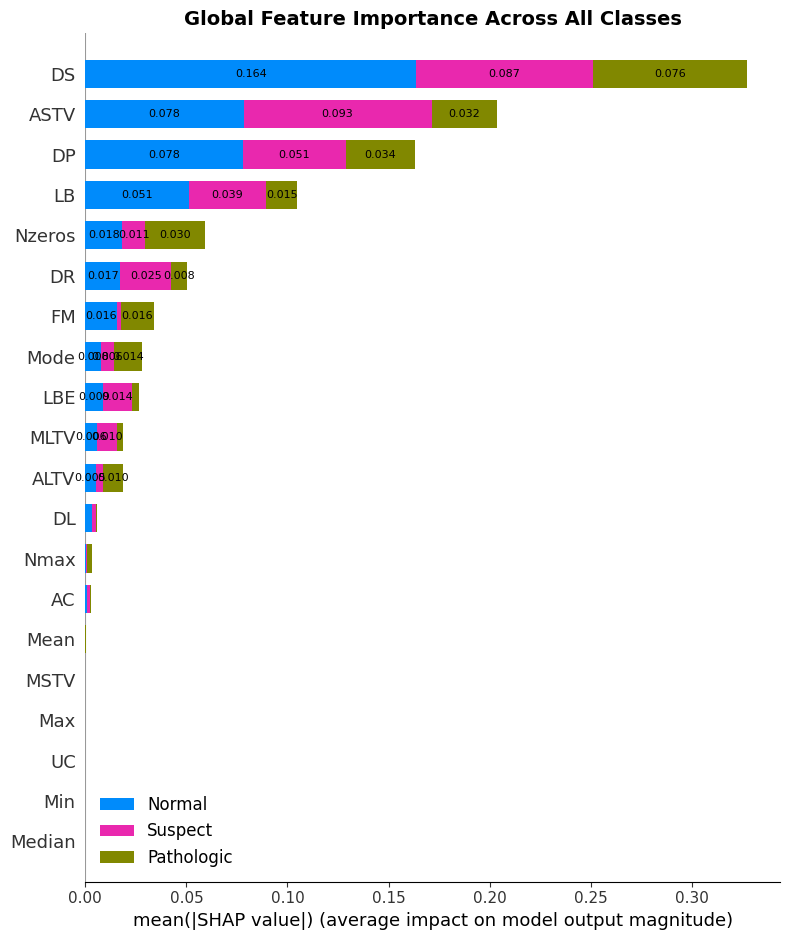

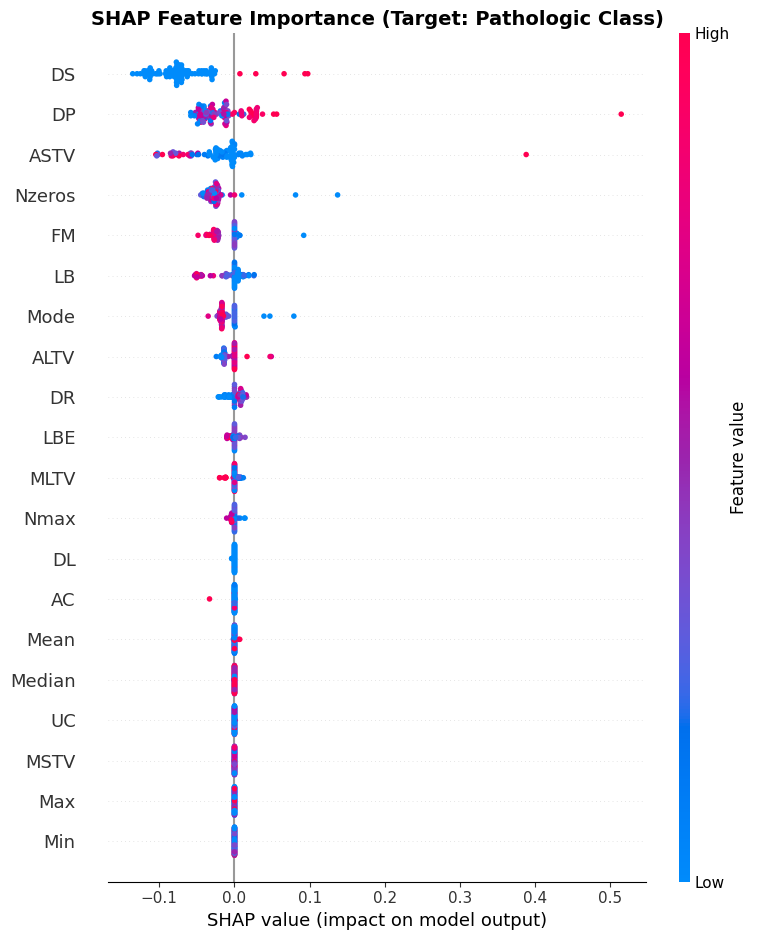

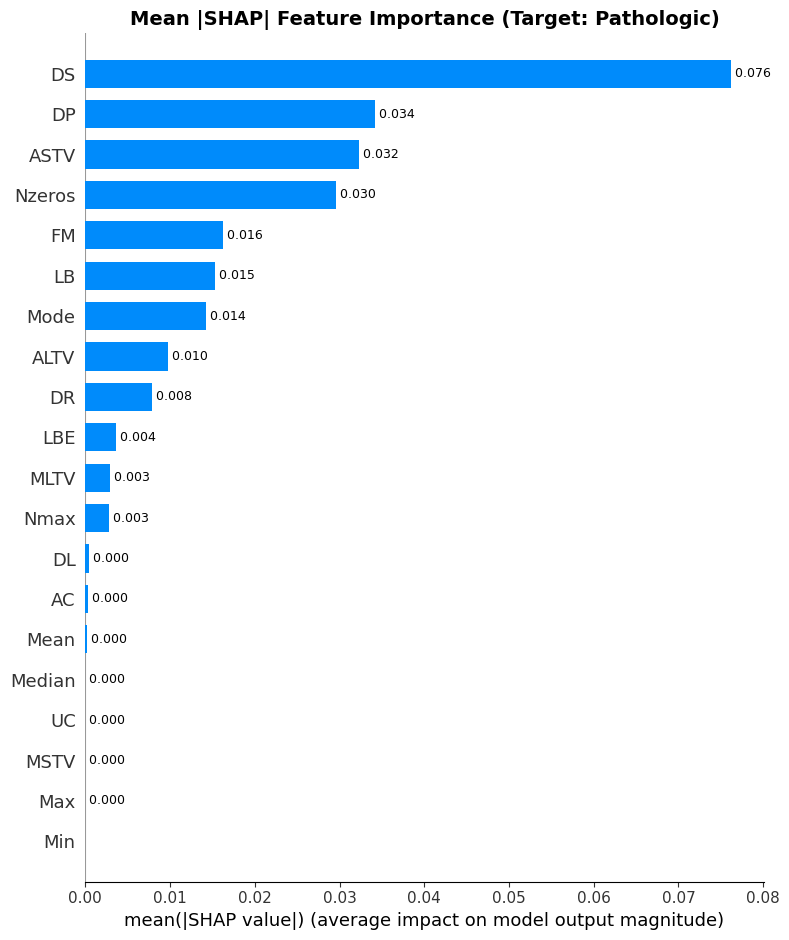

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [ ]:
# =============================================================================
# EXTENDED DYNAMIC SHAP ANALYSIS FOR EW-DDBS WINNING MODEL
# =============================================================================
# Kode ini menghasilkan visualisasi SHAP yang komprehensif untuk publikasi
# di jurnal Scopus Q1 (Intelligent Medicine). Visualisasi mencakup:
#   - Summary plot (beeswarm)
#   - Bar plot (mean |SHAP|) - Target Class & Multiclass
#   - Dependence plots untuk 6 fitur teratas
#   - Waterfall plots untuk kasus True Positive, False Negative, False Positive
#   - Interaction plots (jika model tree-based)
#
# Dibangun di atas kerangka EW‑DDBS (Entropy‑Weighted Dynamic Deep Borderline‑SMOTE).
# =============================================================================

import logging
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from typing import Optional, Tuple, Union, List
import inspect

# -----------------------------------------------------------------------------
# 1. LOGGING & KONFIGURASI
# -----------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)
shap.initjs()

# -----------------------------------------------------------------------------
# 2. FUNGSI PERSIAPAN DATA
# -----------------------------------------------------------------------------
def prepare_data_for_shap(
    X: Union[pd.DataFrame, np.ndarray],
    y: Union[pd.Series, np.ndarray],
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    """Split dan scaling data."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    logger.info(f"Data siap: train shape={X_train_scaled.shape}, test shape={X_test_scaled.shape}")
    y_tr = y_train.values if hasattr(y_train, 'values') else y_train
    y_te = y_test.values if hasattr(y_test, 'values') else y_test
    return X_train_scaled, X_test_scaled, y_tr, y_te, scaler

def apply_ew_ddbs_resampling(
    X_train: np.ndarray,
    y_train: np.ndarray,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray]:
    """Resampling dengan EW‑DDBS (Safe+Tomek)."""
    logger.info("Menerapkan resampling EW‑DDBS (Safe+Tomek)...")
    # Memanggil fungsi asli dari namespace global
    entropy, deep_feats = get_cnn_guidance_v2(X_train, y_train)
    X_bal, y_bal = run_ew_ddbs_v3(
        X_train, y_train, entropy, deep_feats,
        use_safe_region=True, apply_tomek=True
    )
    logger.info(f"Data setelah resampling: shape={X_bal.shape}, distribusi kelas={np.bincount(y_bal)}")
    return X_bal, y_bal

def get_winning_classifier_name(
    df_results: pd.DataFrame,
    proposed_method: str = "PROPOSED (Safe+Tomek)"
) -> str:
    """Identifikasi classifier dengan F1‑Macro tertinggi."""
    mask = df_results['Oversampling'] == proposed_method
    proposed_results = df_results[mask]
    mean_f1 = proposed_results.groupby('Classifier')['F1-Macro'].mean()
    best_classifier = mean_f1.idxmax()
    logger.info(f"Classifier pemenang: {best_classifier} (F1-Macro rata-rata = {mean_f1.max():.4f})")
    return best_classifier

def train_winning_model(
    classifier_name: str,
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_iter: int = 15,
    cv: int = 3
) -> BaseEstimator:
    """Latih model pemenang pada data seimbang."""
    logger.info(f"Melatih (dengan tuning) classifier: {classifier_name}")
    # Memanggil fungsi asli dari namespace global
    model = get_classifier_with_tuning(classifier_name, X_train, y_train, n_iter=n_iter, cv=cv)
    model.fit(X_train, y_train)
    logger.info("Pelatihan model selesai.")
    return model

# -----------------------------------------------------------------------------
# 3. FUNGSI KOMPUTASI SHAP
# -----------------------------------------------------------------------------
def compute_shap_values(
    model: BaseEstimator,
    X_test: np.ndarray,
    X_train_bal: np.ndarray,
    classifier_name: str,
    n_background: int = 50,
    max_test_samples: Optional[int] = 100
) -> Tuple[Union[np.ndarray, list], Union[np.ndarray, list], np.ndarray, shap.Explainer]:
    """Hitung SHAP values untuk semua kelas dan spesifik untuk kelas target."""
    tree_based = {"RF", "XGB", "AdaBoost", "ExtraTrees", "DT"}

    if classifier_name in tree_based:
        logger.info(f"Menggunakan TreeExplainer untuk {classifier_name}.")
        explainer = shap.TreeExplainer(model)
        X_eval = X_test
        shap_vals = explainer.shap_values(X_eval)
    else:
        logger.info(f"Menggunakan KernelExplainer untuk {classifier_name} (mungkin memakan waktu).")
        background = shap.kmeans(X_train_bal, n_background)
        explainer = shap.KernelExplainer(model.predict_proba, background)
        n_eval = min(X_test.shape[0], max_test_samples) if max_test_samples else X_test.shape[0]
        X_eval = X_test[:n_eval]
        shap_vals = explainer.shap_values(X_eval)
        logger.info(f"SHAP dihitung pada {n_eval} sampel uji.")

    # Ekstrak SHAP untuk kelas target (Pathologic = indeks 2)
    if isinstance(shap_vals, list):
        if len(shap_vals) > 2:
            shap_target = shap_vals[2]
        else:
            shap_target = shap_vals[0]
    elif len(shap_vals.shape) == 3:
        shap_target = shap_vals[:, :, 2]
    else:
        shap_target = shap_vals

    return shap_vals, shap_target, X_eval, explainer

# -----------------------------------------------------------------------------
# 4. FUNGSI PLOTTING TAMBAHAN
# -----------------------------------------------------------------------------
def compare_multiclass_shap(
    shap_vals: Union[np.ndarray, list],
    feature_names: List[str],
    class_names: List[str]
) -> None:
    """Kalkulasi dan log perbandingan mean |SHAP| untuk semua kelas."""
    logger.info("=== Global Mean |SHAP| Comparison Across Classes ===")
    if isinstance(shap_vals, np.ndarray) and len(shap_vals.shape) == 3:
        vals = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]
    elif isinstance(shap_vals, list):
        vals = shap_vals
    else:
        vals = [shap_vals]

    for i, class_name in enumerate(class_names):
        if i < len(vals):
            mean_abs_shap = np.abs(vals[i]).mean(axis=0)
            top_indices = np.argsort(mean_abs_shap)[::-1][:5]
            top_feats = [(feature_names[idx], mean_abs_shap[idx]) for idx in top_indices]
            feats_str = ", ".join([f"{name} ({val:.4f})" for name, val in top_feats])
            logger.info(f"Class {class_name} Top 5 Features: {feats_str}")

def plot_shap_multiclass_bar(
    shap_vals: Union[np.ndarray, list],
    features: np.ndarray,
    feature_names: List[str],
    class_names: List[str],
    save_path: Optional[str] = None,
    dpi: int = 300,
    figsize: Tuple[int, int] = (10, 6)
) -> None:
    """SHAP bar plot multiclass (stacked mean |SHAP|)."""
    plt.figure(figsize=figsize)
    plot_vals = shap_vals
    if isinstance(shap_vals, np.ndarray) and len(shap_vals.shape) == 3:
        plot_vals = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]

    shap.summary_plot(
        plot_vals, features, feature_names=feature_names,
        plot_type="bar", show=False, class_names=class_names
    )
    plt.title("Global Feature Importance Across All Classes", fontsize=14, fontweight='bold')

    # Menambahkan nilai di tengah masing-masing bagian stacked bar
    ax = plt.gca()
    for p in ax.patches:
        width = p.get_width()
        # Hanya tampilkan nilai jika cukup besar agar tidak terlalu padat
        if width > 0.005:
            x = p.get_x() + width / 2
            y = p.get_y() + p.get_height() / 2
            ax.text(x, y, f'{width:.3f}', ha='center', va='center', fontsize=8, color='black')

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        logger.info(f"Multiclass bar plot disimpan di {save_path}")
    plt.show()
    plt.close()

def plot_shap_summary(
    shap_values: np.ndarray,
    features: np.ndarray,
    feature_names: List[str],
    save_path: Optional[str] = None,
    dpi: int = 300,
    figsize: Tuple[int, int] = (10, 6)
) -> None:
    """SHAP summary plot (beeswarm) untuk satu kelas."""
    plt.figure(figsize=figsize)
    shap.summary_plot(shap_values, features, feature_names=feature_names, show=False)
    plt.title("SHAP Feature Importance (Target: Pathologic Class)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        logger.info(f"Summary plot disimpan di {save_path}")
    plt.show()
    plt.close()

def plot_shap_bar(
    shap_values: np.ndarray,
    feature_names: List[str],
    save_path: Optional[str] = None,
    dpi: int = 300,
    figsize: Tuple[int, int] = (10, 6)
) -> None:
    """SHAP bar plot (mean |SHAP|) untuk satu kelas."""
    plt.figure(figsize=figsize)
    shap.summary_plot(shap_values, None, feature_names=feature_names,
                      plot_type="bar", show=False)
    plt.title("Mean |SHAP| Feature Importance (Target: Pathologic)", fontsize=14, fontweight='bold')

    # Menambahkan teks nilai di samping batang
    ax = plt.gca()
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width, p.get_y() + p.get_height() / 2, f' {width:.3f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        logger.info(f"Bar plot disimpan di {save_path}")
    plt.show()
    plt.close()

def plot_shap_dependence(
    shap_values: np.ndarray,
    features: np.ndarray,
    feature_names: List[str],
    top_k: int = 6,
    save_dir: str = "./figures/shap_dependence",
    dpi: int = 300
) -> None:
    """SHAP dependence plots untuk top_k fitur."""
    os.makedirs(save_dir, exist_ok=True)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_indices = np.argsort(mean_abs_shap)[-top_k:][::-1]

    for idx in top_indices:
        plt.figure(figsize=(8, 5))
        shap.dependence_plot(
            idx, shap_values, features,
            feature_names=feature_names,
            show=False
        )
        plt.title(f"SHAP Dependence: {feature_names[idx]}", fontweight='bold')
        plt.tight_layout()
        fname = feature_names[idx].replace('/', '_')
        plt.savefig(f"{save_dir}/shap_dep_{fname}.png", dpi=dpi, bbox_inches='tight')
        plt.close()
        logger.info(f"Dependence plot untuk {feature_names[idx]} disimpan.")

def explain_individual_cases(
    shap_values: np.ndarray,
    X_eval: np.ndarray,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    feature_names: List[str],
    explainer: shap.Explainer,
    save_dir: str = "./figures/shap_individual",
    dpi: int = 300
) -> None:
    """Waterfall plots untuk kasus TP, FN, FP."""
    os.makedirs(save_dir, exist_ok=True)
    target_class = 2  # Pathologic

    tp_candidates = np.where((y_true == target_class) & (y_pred == target_class))[0]
    fn_candidates = np.where((y_true == target_class) & (y_pred != target_class))[0]
    fp_candidates = np.where((y_true != target_class) & (y_pred == target_class))[0]

    base_value = explainer.expected_value
    if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
        base_value = base_value[target_class] if len(base_value) > target_class else base_value[0]

    # Pastikan base_value adalah float scalar
    if isinstance(base_value, np.ndarray):
        if base_value.size == 1:
            base_value = float(base_value.item())
        else:
            # Ambil elemen pertama jika tetap ada dimensi, atau sesuaikan logikanya
            base_value = float(base_value[0])
    else:
        base_value = float(base_value)

    def plot_waterfall(idx, case_type):
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values[idx],
                base_values=base_value,
                data=X_eval[idx],
                feature_names=feature_names
            ),
            show=False
        )
        plt.title(f"SHAP Waterfall - {case_type} Case (True={y_true[idx]}, Pred={y_pred[idx]})",
                  fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"{save_dir}/waterfall_{case_type}_idx{idx}.png", dpi=dpi, bbox_inches='tight')
        plt.close()
        logger.info(f"Waterfall plot untuk {case_type} (index {idx}) disimpan.")

    if len(tp_candidates) > 0:
        plot_waterfall(tp_candidates[0], "TP")
    else:
        logger.warning("Tidak ada kasus True Positive ditemukan.")
    if len(fn_candidates) > 0:
        plot_waterfall(fn_candidates[0], "FN")
    else:
        logger.warning("Tidak ada kasus False Negative ditemukan.")
    if len(fp_candidates) > 0:
        plot_waterfall(fp_candidates[0], "FP")
    else:
        logger.warning("Tidak ada kasus False Positive ditemukan.")

def plot_shap_interaction(
    model: BaseEstimator,
    X_eval: np.ndarray,
    feature_names: List[str],
    top_features: List[str] = None,
    save_dir: str = "./figures/shap_interaction",
    dpi: int = 300
) -> None:
    """SHAP interaction plots untuk pasangan fitur teratas."""
    if not hasattr(model, 'predict_proba'):
        logger.warning("Model tidak mendukung predict_proba, interaction plot dilewati.")
        return
    explainer = shap.TreeExplainer(model)
    shap_interaction = explainer.shap_interaction_values(X_eval)
    if isinstance(shap_interaction, list):
        shap_interaction = shap_interaction[2]
    os.makedirs(save_dir, exist_ok=True)

    if top_features is None:
        mean_abs_shap = np.abs(shap_interaction).mean(axis=(0,2))
        top_indices = np.argsort(mean_abs_shap)[-3:][::-1]
        top_features = [feature_names[i] for i in top_indices]

    for i, f1 in enumerate(top_features):
        for f2 in top_features[i+1:]:
            idx1 = feature_names.index(f1)
            idx2 = feature_names.index(f2)
            plt.figure(figsize=(8, 6))
            shap.dependence_plot(
                (idx1, idx2), shap_interaction, X_eval,
                feature_names=feature_names, show=False
            )
            plt.title(f"SHAP Interaction: {f1} × {f2}", fontweight='bold')
            plt.tight_layout()
            fname = f"{f1}_{f2}".replace('/', '_')
            plt.savefig(f"{save_dir}/interact_{fname}.png", dpi=dpi, bbox_inches='tight')
            plt.close()
            logger.info(f"Interaction plot {f1} × {f2} disimpan.")

# -----------------------------------------------------------------------------
# 5. FUNGSI UTAMA (ORCHESTRATOR)
# -----------------------------------------------------------------------------
def perform_shap_analysis_extended(
    df_results: pd.DataFrame,
    X: Union[pd.DataFrame, np.ndarray],
    y: Union[pd.Series, np.ndarray],
    feature_names: Optional[List[str]] = None,
    random_state: int = 42,
    output_dir: str = "./figures"
) -> None:
    """
    Melakukan analisis SHAP lengkap untuk model pemenang EW‑DDBS.
    """
    logger.info("=" * 70)
    logger.info("MEMULAI ANALISIS SHAP DIPERLUAS UNTUK MODEL PEMENANG EW‑DDBS")
    logger.info("=" * 70)

    # 1. Nama fitur (dataset CTG)
    if feature_names is None:
        feature_names = [
            'LBE', 'LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR',
            'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max',
            'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median'
        ]
    class_names = ["Normal", "Suspect", "Pathologic"]

    # 2. Persiapan data
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_data_for_shap(
        X, y, test_size=0.2, random_state=random_state
    )

    # 3. Identifikasi classifier terbaik
    best_classifier = get_winning_classifier_name(df_results)

    # 4. Resampling EW‑DDBS
    X_train_bal, y_train_bal = apply_ew_ddbs_resampling(
        X_train_scaled, y_train, random_state=random_state
    )

    # 5. Latih model
    model = train_winning_model(best_classifier, X_train_bal, y_train_bal)

    # 6. Hitung SHAP values (semua kelas & target kelas)
    shap_vals, shap_target, X_eval, explainer = compute_shap_values(
        model=model,
        X_test=X_test_scaled,
        X_train_bal=X_train_bal,
        classifier_name=best_classifier,
        n_background=50,
        max_test_samples=100
    )

    # 7. Prediksi pada X_eval untuk analisis waterfall
    y_pred_eval = model.predict(X_eval)
    if len(X_eval) < len(y_test):
        y_true_eval = y_test[:len(X_eval)]
    else:
        y_true_eval = y_test

    # 8. Hasilkan visualisasi Multiclass Global (BARU)
    compare_multiclass_shap(shap_vals, feature_names, class_names)
    plot_shap_multiclass_bar(
        shap_vals, X_eval, feature_names, class_names,
        save_path=os.path.join(output_dir, "shap_bar_multiclass.png")
    )

    # 9. Hasilkan visualisasi spesifik untuk Kelas Target
    plot_shap_summary(
        shap_target, X_eval, feature_names,
        save_path=os.path.join(output_dir, "shap_summary_beeswarm.png")
    )
    plot_shap_bar(
        shap_target, feature_names,
        save_path=os.path.join(output_dir, "shap_bar_mean_target.png")
    )
    plot_shap_dependence(
        shap_target, X_eval, feature_names, top_k=6,
        save_dir=os.path.join(output_dir, "shap_dependence")
    )
    explain_individual_cases(
        shap_target, X_eval, y_true_eval, y_pred_eval, feature_names,
        explainer, save_dir=os.path.join(output_dir, "shap_individual")
    )

    # Interaction plots hanya untuk model tree-based
    tree_based = {"RF", "XGB", "AdaBoost", "ExtraTrees", "DT"}
    if best_classifier in tree_based:
        plot_shap_interaction(
            model, X_eval, feature_names,
            save_dir=os.path.join(output_dir, "shap_interaction")
        )
    else:
        logger.info(f"Model {best_classifier} bukan tree-based, interaction plot dilewati.")

    logger.info("Analisis SHAP diperluas selesai.")
    logger.info("Referensi: Lundberg & Lee (2017). A Unified Approach to Interpreting Model Predictions. NeurIPS.")
    logger.info("=" * 70)

# -----------------------------------------------------------------------------
# 6. EKSEKUSI
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    # Pastikan fungsi asli tidak menggunakan versi placeholder
    if "NotImplementedError" in inspect.getsource(get_cnn_guidance_v2):
        raise RuntimeError("PENTING: Kernel masih menggunakan versi placeholder dari get_cnn_guidance_v2. "
                           "Silakan jalankan ulang sel NILQaIKQCtjW terlebih dahulu untuk memuat ulang fungsi asli.")

    # Jalankan analisis menggunakan df_results, X, y dari namespace global
    perform_shap_analysis_extended(
        df_results=df_results,
        X=X,
        y=y,
        output_dir="./figures_extended"
    )


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ================== PATCH-D : WILCOXON ABLATION TEST ==================
# Runs after Cell 3. Uses df_results in memory.
# Pairs each (Fold, Classifier) so the comparison is properly paired.

from scipy.stats import wilcoxon
import pandas as pd

ABLATION_PAIRS = [
    ("PROPOSED (Entropy only)",  "PROPOSED (Entropy+Tomek)", "F1-Macro"),
    ("PROPOSED (Safe only)",     "PROPOSED (Safe+Tomek)",    "F1-Macro"),
    ("PROPOSED (Entropy only)",  "PROPOSED (Entropy+Tomek)", "AUPRC"),
    ("PROPOSED (Safe only)",     "PROPOSED (Safe+Tomek)",    "AUPRC"),
    ("PROPOSED (Entropy+Tomek)", "PROPOSED (Safe+Tomek)",    "F1-Macro"),
    ("PROPOSED (Entropy+Tomek)", "PROPOSED (Safe+Tomek)",    "AUPRC"),
]

print("=== Wilcoxon signed-rank tests for ablation pairs ===")
print("(paired by Fold x Classifier; N = 5 folds x 15 classifiers = 75 pairs)\n")

rows = []
for a, b, m in ABLATION_PAIRS:
    sub_a = (df_results[df_results['Oversampling'] == a]
             .set_index(['Fold', 'Classifier'])[m].sort_index())
    sub_b = (df_results[df_results['Oversampling'] == b]
             .set_index(['Fold', 'Classifier'])[m].sort_index())

    common = sub_a.index.intersection(sub_b.index)
    sub_a = sub_a.loc[common]
    sub_b = sub_b.loc[common]

    diff = sub_b.values - sub_a.values
    median_diff = float(pd.Series(diff).median())
    mean_diff   = float(pd.Series(diff).mean())

    if (diff == 0).all():
        stat, p = float('nan'), float('nan')
    else:
        stat, p = wilcoxon(sub_a.values, sub_b.values,
                           zero_method='wilcox', alternative='two-sided')

    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    rows.append({
        'metric':    m,
        'A':         a,
        'B':         b,
        'n_pairs':   len(diff),
        'median_diff_B_minus_A': round(median_diff, 4),
        'mean_diff_B_minus_A':   round(mean_diff, 4),
        'wilcoxon_stat': None if pd.isna(stat) else round(stat, 3),
        'p_value':       None if pd.isna(p)    else round(p, 4),
        'sig_alpha_0.05': sig,
    })

wilcoxon_df = pd.DataFrame(rows)
print(wilcoxon_df.to_string(index=False))
wilcoxon_df.to_csv("ablation_wilcoxon_refined.csv", index=False)
print("\nSaved to ablation_wilcoxon_refined.csv")


=== Wilcoxon signed-rank tests for ablation pairs ===
(paired by Fold x Classifier; N = 5 folds x 15 classifiers = 75 pairs)

  metric                        A                        B  n_pairs  median_diff_B_minus_A  mean_diff_B_minus_A  wilcoxon_stat  p_value sig_alpha_0.05
F1-Macro  PROPOSED (Entropy only) PROPOSED (Entropy+Tomek)       75                -0.0004              -0.0029         1138.0   0.1789             ns
F1-Macro     PROPOSED (Safe only)    PROPOSED (Safe+Tomek)       75                 0.0003              -0.0008         1346.0   0.6766             ns
   AUPRC  PROPOSED (Entropy only) PROPOSED (Entropy+Tomek)       75                -0.0016              -0.0014         1267.0   0.4041             ns
   AUPRC     PROPOSED (Safe only)    PROPOSED (Safe+Tomek)       75                -0.0013              -0.0028         1056.0   0.0514             ns
F1-Macro PROPOSED (Entropy+Tomek)    PROPOSED (Safe+Tomek)       75                 0.0029               0.0049        